# Non-mattress 시장 분석

In [150]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [152]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [154]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [158]:

sql = f"""
select * from wook.stckln_amz_non_mattress_ms_trend 
"""

df = bqclient.query(sql).to_dataframe()

In [160]:
print(df)

        RetailerSku       category  subcategory    cn_category cn_subcategory  \
0        B0D2NGFPTL  PLATFORM BEDS  METAL FRAME           None           None   
1        B0D6G6KS24  PLATFORM BEDS  METAL FRAME           None           None   
2        B0DMNCFFNK  PLATFORM BEDS  METAL FRAME           None           None   
3        B0CM5FC2ZN  PLATFORM BEDS  METAL FRAME           None           None   
4        B0CM5JMFN6  PLATFORM BEDS  METAL FRAME           None           None   
...             ...            ...          ...            ...            ...   
2201777  B01K8O376Q  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   
2201778  B01K8O376Q  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   
2201779  B092PVZ2PP  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   
2201780  B092PF35H9  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   
2201781  B092M2NYQK  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   

          gpt_category gpt_

In [162]:
df['RetailerSku'].nunique()

135924

In [164]:
df['Brand_raw'].nunique()

3109

In [166]:
# WeekEnding이 object 타입이라면 datetime으로 변환
df['WeekEnding'] = pd.to_datetime(df['WeekEnding'], errors='coerce')

# 연도 컬럼 추가
df['year'] = df['WeekEnding'].dt.year
df['year'].isna().sum()

0

In [168]:
df['yr_half'] = df['yr_month'].apply(
    lambda ym: f"{ym.split('-')[0]}-H1" if int(ym.split('-')[1]) <= 6 else f"{ym.split('-')[0]}-H2"
)

In [170]:
# 변경할 category 목록
target_categories = [
    'FOAM MATTRESSES',
    'FOAM MATTRESSES+METAL BED FRAME',
    'NON BEDROOM FUR',
    'SMARTBASES+OTHERS',
    'SPRING MATTRESS',
    'SPRING MATTRESS+BOX SPRINGS',
    'SOFA',
    'TOPPERS'
]

# 변경할 값 (예시로 모두 'MATTRESS'로)
change_to = 'OTHERS'

# category 값 변경
df['category'] = df['category'].apply(lambda x: change_to if x in target_categories else x)

# 결과 확인
print(df['category'].value_counts())

category
PLATFORM BEDS      1559124
OTH.FRAMES&BEDS     375902
OTHERS              137565
BOX SPRINGS          99110
SMARTBASES           30081
Name: count, dtype: int64


In [172]:
df.head(5)

,RetailerSku,category,subcategory,cn_category,cn_subcategory,gpt_category,gpt_subcategory,bsr_ctgry_label,Brand_raw,Brand_adj,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B0D2NGFPTL,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,06. Beds,YICENSEN,YICENSEN,...,9,109.99,24-4,24-10,Y24 W41,Y24 W41,508517.99,224187.88,2024,24-H2
1,B0D6G6KS24,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,05. Bed Frames,LUTOWN-TEEN,LUTOWN-TEEN,...,1,75.99,25-1,25-02,Y25 W06,Y25 W06,10027097.66,2608585.77,2025,25-H1
2,B0DMNCFFNK,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,05. Bed Frames,VIPSHOW,VIPSHOW,...,1,118.89,25-2,25-05,Y25 W20,Y25 W20,1336078.40,954237.16,2025,25-H1
3,B0CM5FC2ZN,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,05. Bed Frames,LAKKURI,LAKKURI,...,8,73.98,25-1,25-02,Y25 W06,Y25 W06,1767115.45,428948.36,2025,25-H1
4,B0CM5JMFN6,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,05. Bed Frames,LAKKURI,LAKKURI,...,14,58.72,25-1,25-03,Y25 W12,Y25 W12,1767115.45,428948.36,2025,25-H1


### 1. 기초 데이터 분석 - Non-Mattress 카테고리

In [96]:
df1 = df.copy()

In [102]:
# 대문자로 변환하여 비교
df1['is_same_upper'] = df1['category'].str.upper() == df1['cn_category'].str.upper()

# 전체 동일한지 여부 확인
all_equal_upper = df1['is_same_upper'].all()
print("모든 값이 (대문자로 변환 후) 동일한가요?:", all_equal_upper)

# 불일치하는 예시 출력 (중복 제거)
if not all_equal_upper:
    mismatch_rows = df1[df1['is_same_upper'] == False][['RetailerSku', 'category', 'subcategory', 'cn_category', 'cn_subcategory']]
    mismatch_rows_unique = mismatch_rows.drop_duplicates()
    print("불일치하는 고유 샘플 (대문자 기준):")
    print(mismatch_rows_unique)

모든 값이 (대문자로 변환 후) 동일한가요?: False
불일치하는 고유 샘플 (대문자 기준):
        RetailerSku       category  subcategory cn_category cn_subcategory
0        B0D3L1JNVR  PLATFORM BEDS  METAL FRAME        None           None
1        B0D3L4KHT3  PLATFORM BEDS  METAL FRAME        None           None
2        B0CM5FC2ZN  PLATFORM BEDS  METAL FRAME        None           None
3        B0D4XX58WQ  PLATFORM BEDS  METAL FRAME        None           None
4        B0C245NVQF         OTHERS       OTHERS        None           None
...             ...            ...          ...         ...            ...
2041858  B0766BHH8R         OTHERS       OTHERS        None           None
2041887  B0F7XZD2FR         OTHERS       OTHERS        None           None
2041889  B09G6XT6J8         OTHERS       OTHERS        None           None
2041892  B0CY5FF559  PLATFORM BEDS      WOOD PB        None           None
2041893  B0CXP9HMKM  PLATFORM BEDS      MIXE PB        None           None

[41700 rows x 5 columns]


In [ ]:
mismatch_rows.to_csv('mismatch_0804.csv', index=False)

#### - 2025년 기준

In [55]:
df1 = df.copy()
df_2025 = df1[df1['year'] == 2025].copy()

In [57]:
# Brand_raw별 매출 합계 집계
asin_sales_2025 = (
    df_2025.groupby('RetailerSku')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = asin_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
asin_sales_2025['Ratio'] = asin_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
asin_sales_2025['Cumul'] = asin_sales_2025['Ratio'].cumsum()

print(asin_sales_2025)

      RetailerSku  RetailSales         Ratio     Cumul
7858   B0B8VQLN6Y   6185588.66  6.376892e-03  0.006377
15106  B0CKQSJ333   5590231.93  5.763122e-03  0.012140
7928   B0B9XM2N74   3386803.97  3.491548e-03  0.015632
12676  B0C9JFV24R   3368304.48  3.472477e-03  0.019104
14095  B0CGKPHL7D   3278696.86  3.380098e-03  0.022484
...           ...          ...           ...       ...
15     B000BYTYDO         4.99  5.144327e-09  1.000000
77     B001U8JNYU         4.25  4.381441e-09  1.000000
41682  B0DX86BL5R         4.00  4.123709e-09  1.000000
294    B00ATSBIIG         3.96  4.082472e-09  1.000000
41679  B0DX7LLK2C         3.25  3.350513e-09  1.000000

[49048 rows x 4 columns]


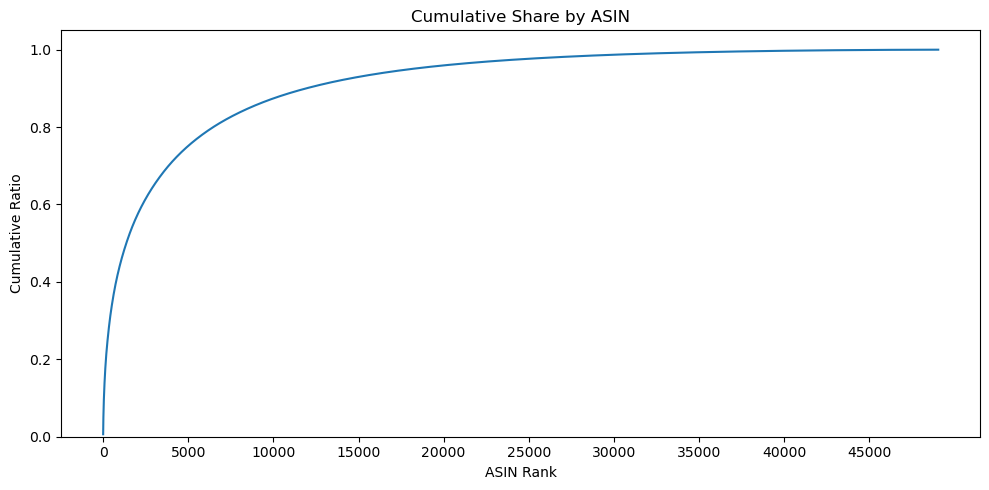

In [61]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(asin_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(10, 5))
plt.plot(x_labels, asin_sales_2025['Cumul'])
plt.title("Cumulative Share by ASIN")
plt.xlabel("ASIN Rank")
plt.ylabel("Cumulative Ratio")
plt.ylim(0, 1.05)

# x축 라벨을 100 단위로 설정
step = 5000
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step])

plt.tight_layout()
plt.show()

In [63]:
asin_sales_2025.to_csv('non_mattress_asin_sales_2025.csv', index=False)

In [65]:
# 2025년 데이터 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = brand_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
brand_sales_2025['Ratio'] = brand_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
brand_sales_2025['Cumul'] = brand_sales_2025['Ratio'].cumsum()
print(brand_sales_2025)

           Brand_raw  RetailSales         Ratio     Cumul
50           ALLEWIE  60970721.41  6.285638e-02  0.062856
1567           ZINUS  41697348.87  4.298693e-02  0.105843
1266      SHA CERLIN  29559838.63  3.047404e-02  0.136317
857          LIKIMIO  25301470.44  2.608397e-02  0.162401
1048        NEW JETO  24195652.00  2.494396e-02  0.187345
...              ...          ...           ...       ...
1211           ROMAN        15.98  1.647422e-08  1.000000
383          DOITOOL        15.69  1.617525e-08  1.000000
1255         SEGMART        13.49  1.390721e-08  1.000000
723           INTEGY         4.99  5.144327e-09  1.000000
174   BIG FISH GAMES         3.96  4.082472e-09  1.000000

[1587 rows x 4 columns]


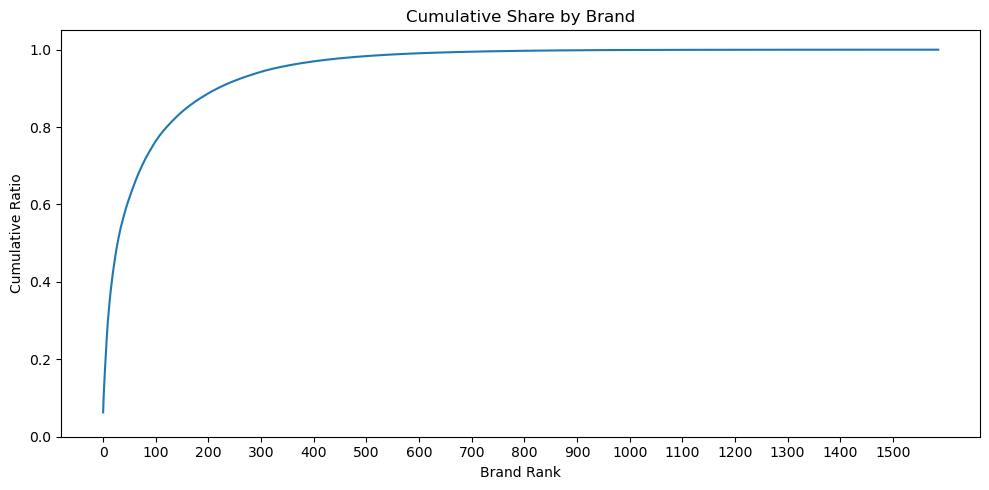

In [67]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(brand_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(10, 5))
plt.plot(x_labels, brand_sales_2025['Cumul'])
plt.title("Cumulative Share by Brand")
plt.xlabel("Brand Rank")
plt.ylabel("Cumulative Ratio")
plt.ylim(0, 1.05)

# x축 라벨을 100 단위로 설정
step = 100
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step])

plt.tight_layout()
plt.show()

In [73]:
print(brand_sales_2025)
brand_sales_2025.to_csv('non_mattress_brand_sales_2025.csv', index=False)

           Brand_raw  RetailSales         Ratio     Cumul
50           ALLEWIE  60970721.41  6.285638e-02  0.062856
1567           ZINUS  41697348.87  4.298693e-02  0.105843
1266      SHA CERLIN  29559838.63  3.047404e-02  0.136317
857          LIKIMIO  25301470.44  2.608397e-02  0.162401
1048        NEW JETO  24195652.00  2.494396e-02  0.187345
...              ...          ...           ...       ...
1211           ROMAN        15.98  1.647422e-08  1.000000
383          DOITOOL        15.69  1.617525e-08  1.000000
1255         SEGMART        13.49  1.390721e-08  1.000000
723           INTEGY         4.99  5.144327e-09  1.000000
174   BIG FISH GAMES         3.96  4.082472e-09  1.000000

[1587 rows x 4 columns]


### 2. 시장 규모 추이

In [174]:
df1 = df.copy()

In [176]:
df1.head(5)

,RetailerSku,category,subcategory,cn_category,cn_subcategory,gpt_category,gpt_subcategory,bsr_ctgry_label,Brand_raw,Brand_adj,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B0D2NGFPTL,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,06. Beds,YICENSEN,YICENSEN,...,9,109.99,24-4,24-10,Y24 W41,Y24 W41,508517.99,224187.88,2024,24-H2
1,B0D6G6KS24,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,05. Bed Frames,LUTOWN-TEEN,LUTOWN-TEEN,...,1,75.99,25-1,25-02,Y25 W06,Y25 W06,10027097.66,2608585.77,2025,25-H1
2,B0DMNCFFNK,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,05. Bed Frames,VIPSHOW,VIPSHOW,...,1,118.89,25-2,25-05,Y25 W20,Y25 W20,1336078.40,954237.16,2025,25-H1
3,B0CM5FC2ZN,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,05. Bed Frames,LAKKURI,LAKKURI,...,8,73.98,25-1,25-02,Y25 W06,Y25 W06,1767115.45,428948.36,2025,25-H1
4,B0CM5JMFN6,PLATFORM BEDS,METAL FRAME,None,None,Platform Beds,Metal No HB,05. Bed Frames,LAKKURI,LAKKURI,...,14,58.72,25-1,25-03,Y25 W12,Y25 W12,1767115.45,428948.36,2025,25-H1


In [178]:
df1.groupby(['year'])['RetailSales'].sum()

year
2021    1.237635e+09
2022    1.467124e+09
2023    1.615446e+09
2024    1.785917e+09
2025    9.700006e+08
Name: RetailSales, dtype: float64

In [180]:
df1_grp = df1.groupby(['category'], as_index=False)['RetailSales'].sum()
total = df1['RetailSales'].sum()
df1_grp['Ratio'] = df1_grp['RetailSales']/total*100
print(df1_grp)

          category   RetailSales      Ratio
0      BOX SPRINGS  5.000268e+08   7.066395
1  OTH.FRAMES&BEDS  1.150128e+09  16.253642
2           OTHERS  2.014955e+08   2.847541
3    PLATFORM BEDS  4.954384e+09  70.015509
4       SMARTBASES  2.700895e+08   3.816913


#### 2.1 파이 차트

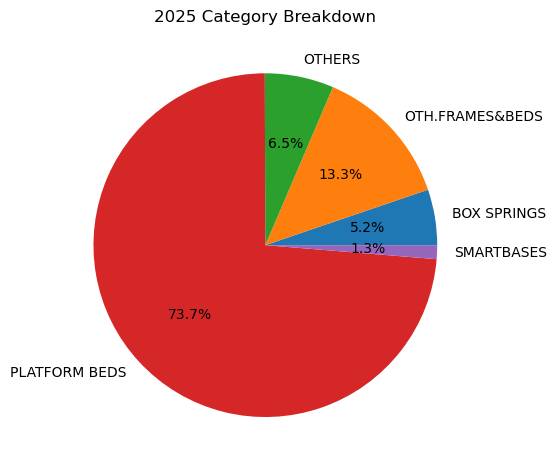

In [183]:
# 2025년 데이터 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# 1. category별 매출 합계 집계
category_sales = df_2025.groupby('category')['RetailSales'].sum()

# 2. Pie Chart
category_sales.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='2025 Category Breakdown')
plt.tight_layout()
plt.show()

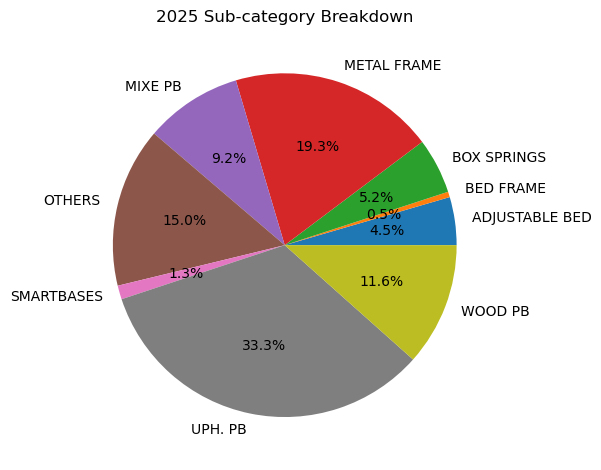

In [185]:
# 1. category별 매출 합계 집계
category_sales = df_2025.groupby('subcategory')['RetailSales'].sum()

# 2. Pie Charts
category_sales.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='2025 Sub-category Breakdown')
plt.tight_layout()
plt.show()

[2021, 2022, 2023, 2024, 2025]


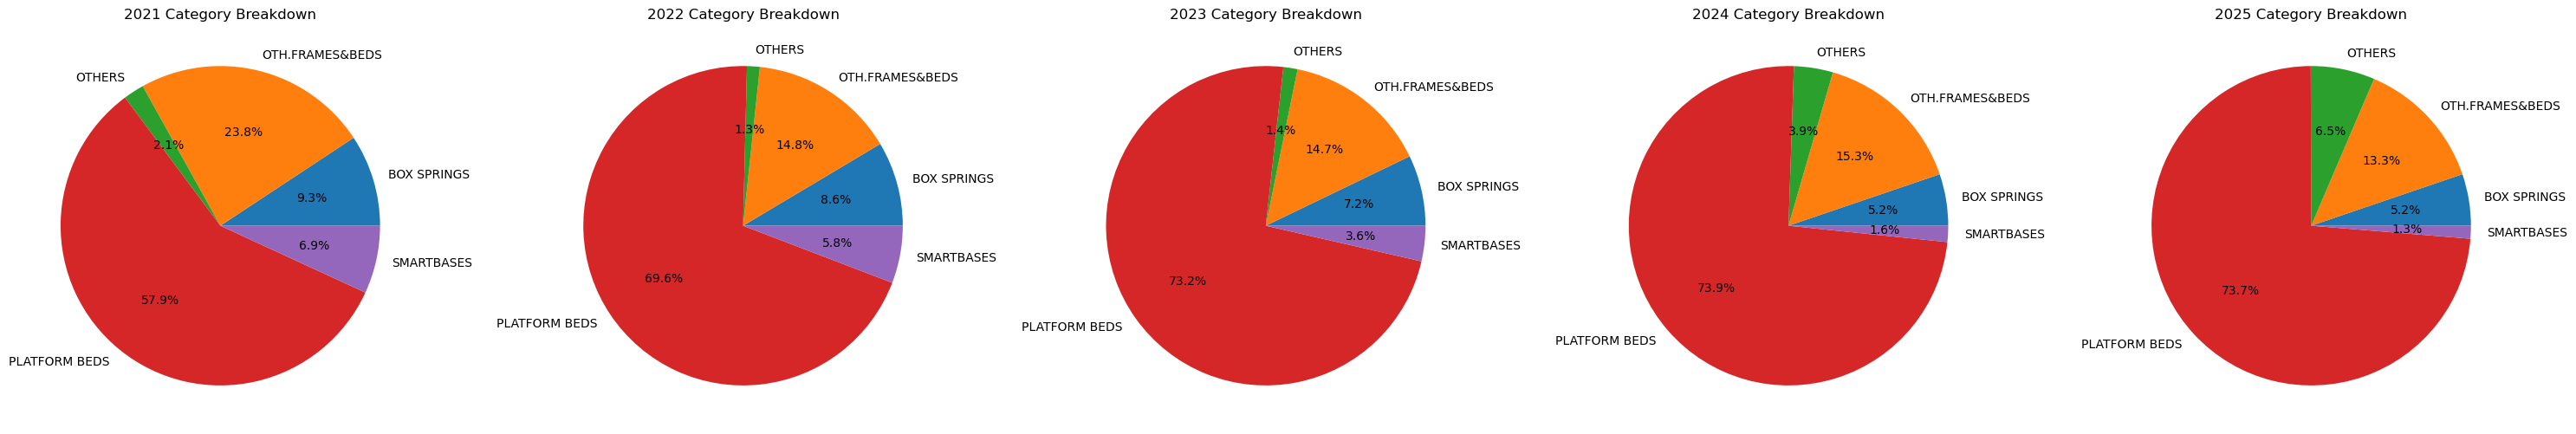

In [135]:
# year 컬럼에서 고유값을 정렬하여 추출
years = sorted(df1['year'].dropna().unique())
print(years)  # [2023, 2024, 2025] 와 같이 출력됨

fig, axes = plt.subplots(1, len(years), figsize=(6*len(years), 6))

for i, year in enumerate(years):
    df_year = df1[df1['year'] == year]
    category_sales = df_year.groupby('category')['RetailSales'].sum()
    category_sales.plot(
        kind='pie',
        autopct='%1.1f%%',
        ylabel='',
        title=f'{year} Category Breakdown',
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

[2021, 2022, 2023, 2024, 2025]


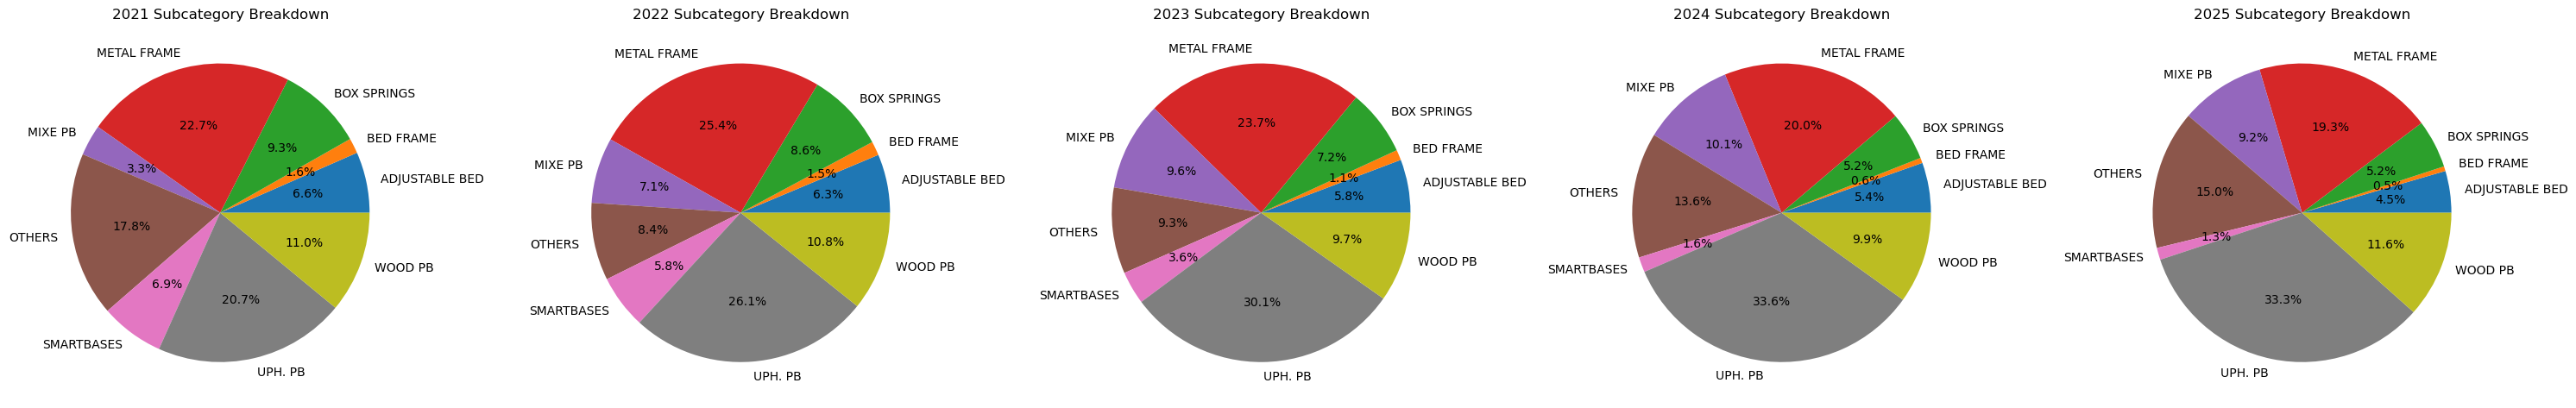

In [137]:
# year 컬럼에서 고유값을 정렬하여 추출
years = sorted(df1['year'].dropna().unique())
print(years)  # [2023, 2024, 2025] 와 같이 출력됨

fig, axes = plt.subplots(1, len(years), figsize=(6*len(years), 6))

for i, year in enumerate(years):
    df_year = df1[df1['year'] == year]
    category_sales = df_year.groupby('subcategory')['RetailSales'].sum()
    category_sales.plot(
        kind='pie',
        autopct='%1.1f%%',
        ylabel='',
        title=f'{year} Subcategory Breakdown',
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

#### 2.2 영역 차트

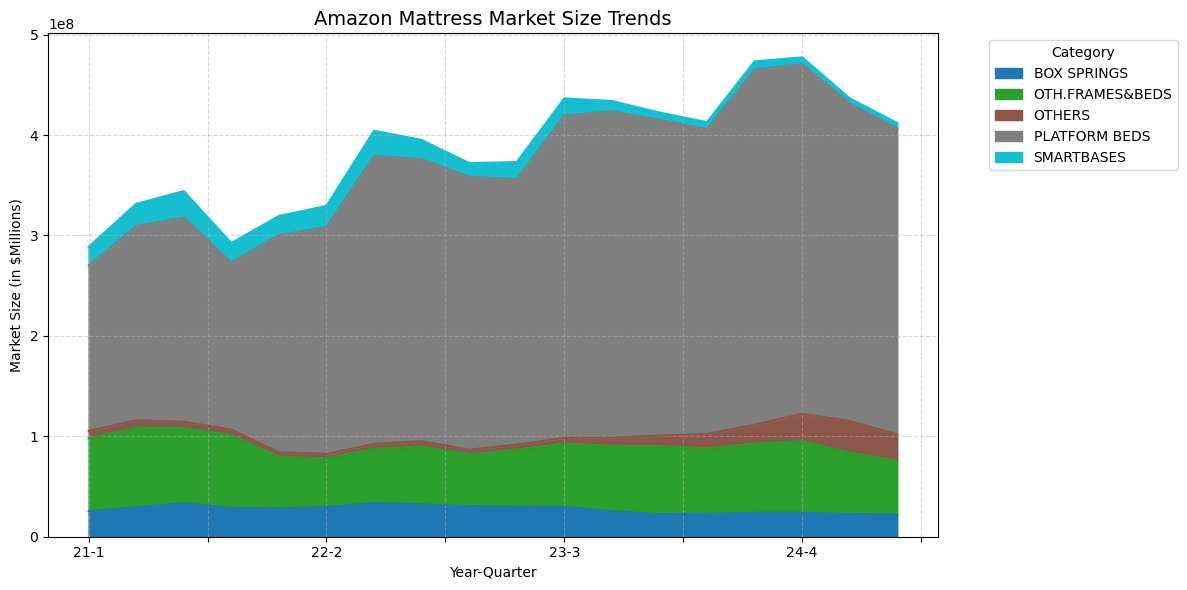

In [143]:
# '25-3' 쿼터 제외
df_filtered = df1[df1['yr_quarter'] != '25-3']

# 2. 세부 카테고리별 월간 매출 합계 집계
df_grouped = df_filtered.groupby(['yr_quarter', 'category'])['RetailSales'].sum().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))  # ✅ 두 개(Figure, Axes)를 반환
df_grouped.plot(kind='area', stacked=True, colormap='tab10', ax=ax)

ax.set_title('Amazon Mattress Market Size Trends', fontsize=14)
ax.set_xlabel('Year-Quarter')
ax.set_ylabel('Market Size (in $Millions)')
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

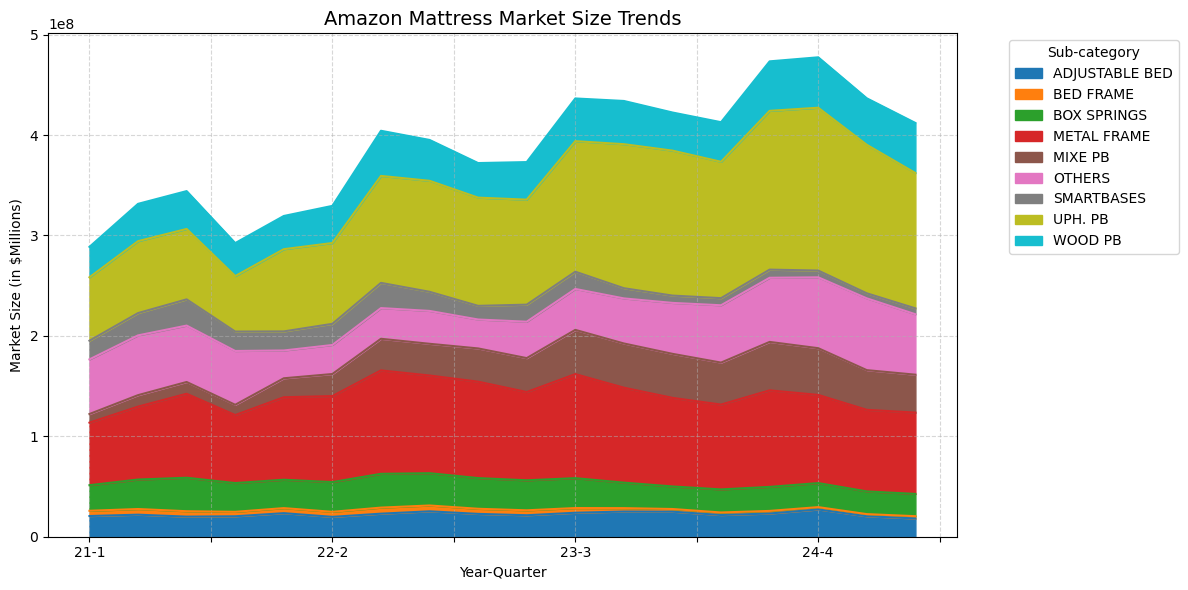

In [141]:
# '25-3' 쿼터 제외
df_filtered = df1[df1['yr_quarter'] != '25-3']

# 2. 세부 카테고리별 월간 매출 합계 집계
df_grouped = df_filtered.groupby(['yr_quarter', 'subcategory'])['RetailSales'].sum().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))  # ✅ 두 개(Figure, Axes)를 반환
df_grouped.plot(kind='area', stacked=True, colormap='tab10', ax=ax)

ax.set_title('Amazon Mattress Market Size Trends', fontsize=14)
ax.set_xlabel('Year-Quarter')
ax.set_ylabel('Market Size (in $Millions)')
ax.legend(title='Sub-category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2.3 Inch별 파이차트 / 영역 차트  --> Non-Mattress는 없음.

In [145]:
print(df1)

        RetailerSku       category  subcategory    cn_category cn_subcategory  \
0        B0D3L1JNVR  PLATFORM BEDS  METAL FRAME           None           None   
1        B0D3L4KHT3  PLATFORM BEDS  METAL FRAME           None           None   
2        B0CM5FC2ZN  PLATFORM BEDS  METAL FRAME           None           None   
3        B0D4XX58WQ  PLATFORM BEDS  METAL FRAME           None           None   
4        B0C245NVQF         OTHERS       OTHERS           None           None   
...             ...            ...          ...            ...            ...   
2201777  B0BW5XV33J  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   
2201778  B0BW5XV33J  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   
2201779  B0CDMYY63C  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   
2201780  B0CJ4S6RNW  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   
2201781  B09G2RQLRD  PLATFORM BEDS      WOOD PB  PLATFORM BEDS        WOOD PB   

          gpt_category gpt_

In [263]:
df1['RetailerSku'].nunique()

23253

#### 2.4 Size별 분석하기

In [86]:
#df1 = df.copy()
df_2025 = df[df['year'] == 2025].copy()

### 3. Price 분석

#### 3.1 가격 분석 (KDE)

In [187]:
df1 = df.copy()

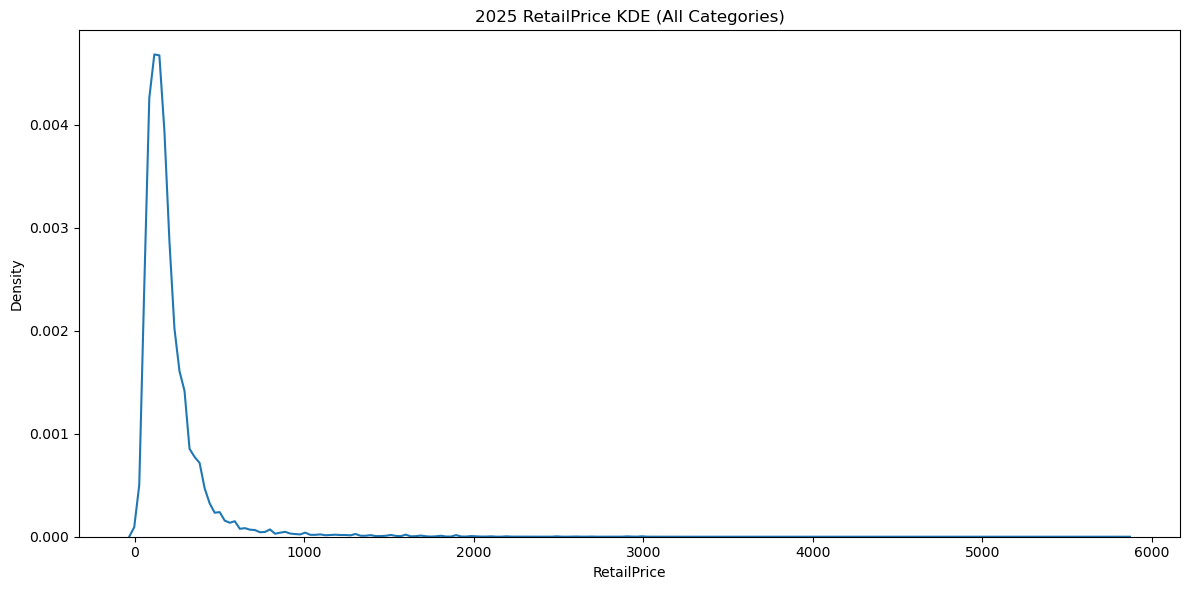

In [189]:
# 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025]

plt.figure(figsize=(12, 6))

# KDE 플롯 (log 변환 없이)
prices = df_2025['RetailPrice'].dropna()
prices = prices[prices > 0]
sns.kdeplot(prices, bw_adjust=0.7)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE (All Categories)')
plt.tight_layout()
plt.show()

['BOX SPRINGS', 'OTH.FRAMES&BEDS', 'OTHERS', 'PLATFORM BEDS', 'SMARTBASES']


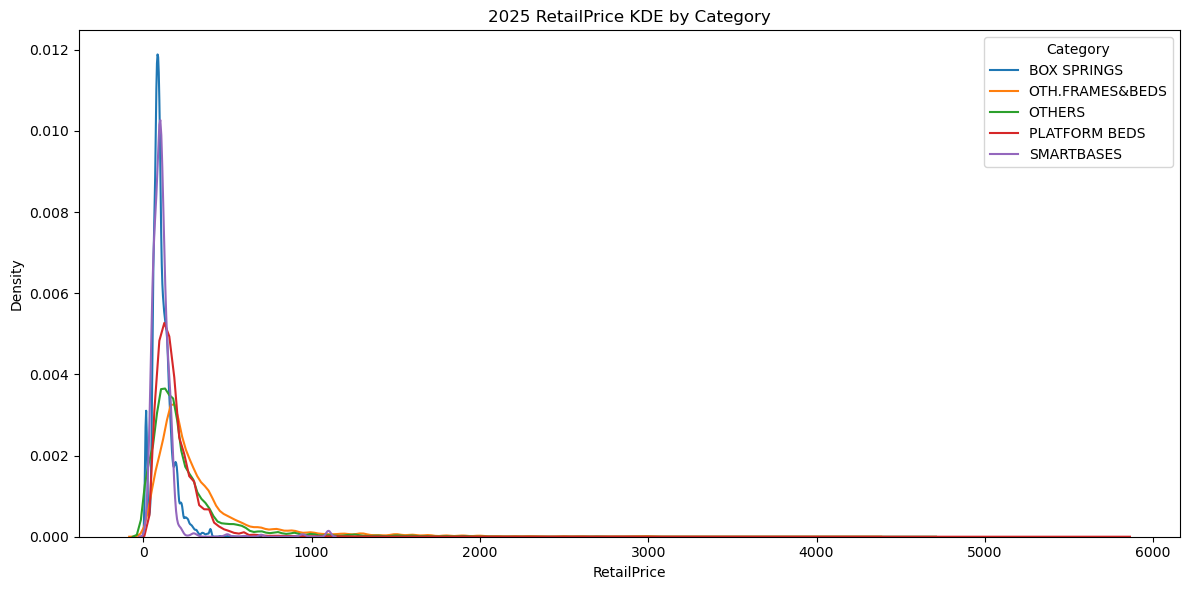

In [191]:
# 2025년 + Foam/Spring만 추출
# 2025년 데이터만 추출
df_2025 = df1[df1['year'] == 2025]

# 데이터에 존재하는 카테고리 리스트 자동 추출
category_list = sorted(df_2025['category'].dropna().unique())
print(category_list)  # 예시: ['Foam Mattress', 'Spring Mattress']

plt.figure(figsize=(12, 6))

# 각 카테고리별 KDE 곡선 그리기 (로그 변환 없이)
for cat in category_list:
    prices = df_2025[df_2025['category'] == cat]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    if not prices.empty:
        sns.kdeplot(prices, label=cat, bw_adjust=0.7)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE by Category')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

['BOX SPRINGS', 'OTH.FRAMES&BEDS', 'OTHERS', 'PLATFORM BEDS', 'SMARTBASES']


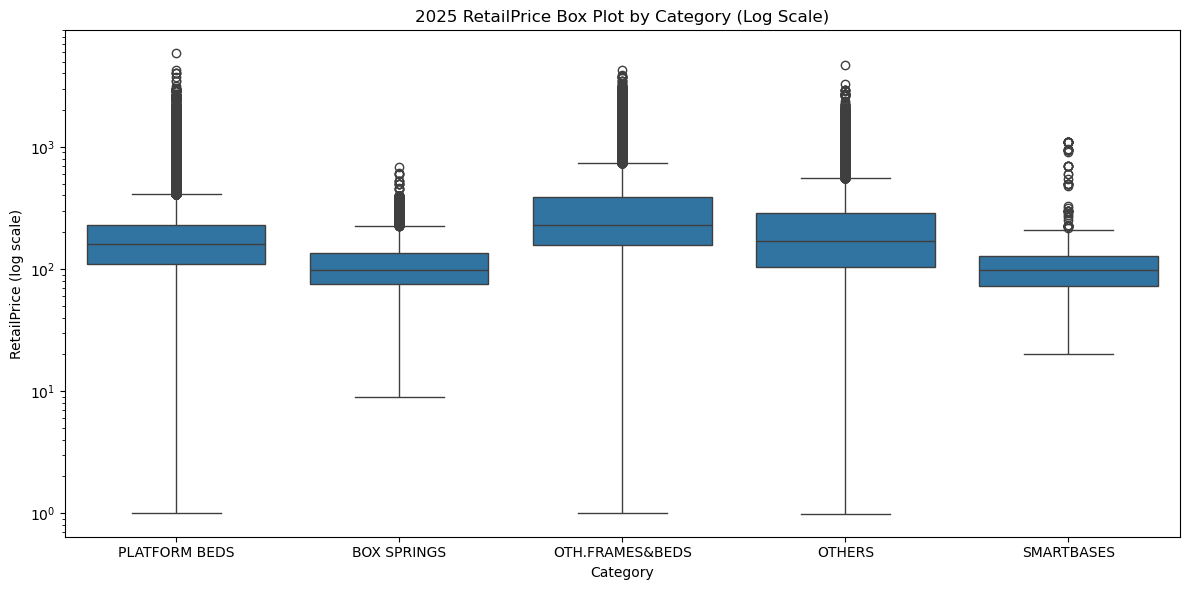

In [201]:
df_2025 = df1[df1['year'] == 2025]

# 카테고리 리스트 추출 (필요시 확인용)
category_list = sorted(df_2025['category'].dropna().unique())
print(category_list)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_2025[df_2025['RetailPrice'] > 0],
    x='category',
    y='RetailPrice'
)
plt.yscale('log')
plt.xlabel('Category')
plt.ylabel('RetailPrice (log scale)')
plt.title('2025 RetailPrice Box Plot by Category (Log Scale)')
plt.tight_layout()
plt.show()

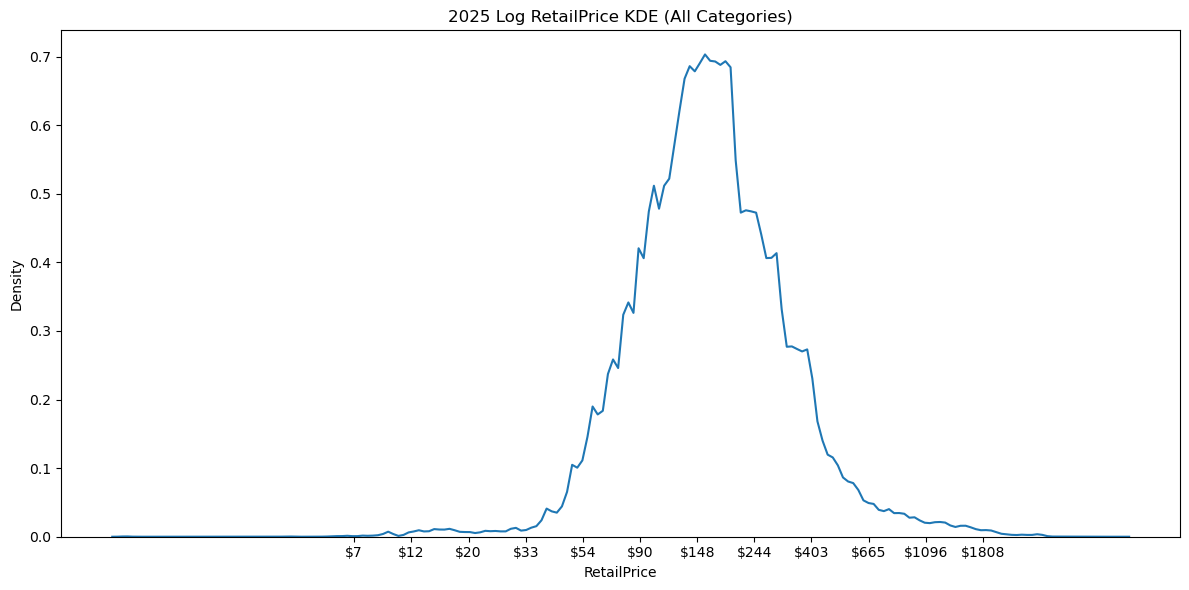

In [193]:
# 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025]

plt.figure(figsize=(12, 6))

# KDE 플롯
prices = df_2025['RetailPrice'].dropna()
prices = prices[prices > 0]
log_prices = np.log(prices)
sns.kdeplot(log_prices, bw_adjust=0.7)

# 로그축 x → 실제 가격으로 표시
xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

plt.xticks(xticks, xtick_labels)
plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 Log RetailPrice KDE (All Categories)')
plt.tight_layout()
plt.show()

['BOX SPRINGS', 'OTH.FRAMES&BEDS', 'OTHERS', 'PLATFORM BEDS', 'SMARTBASES']


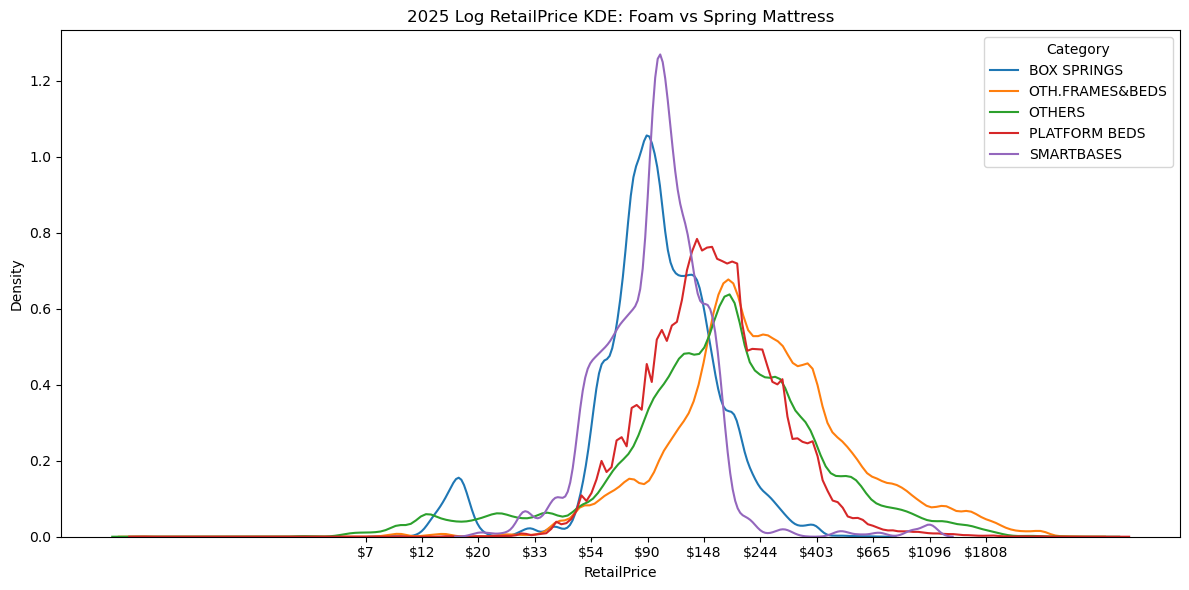

In [195]:
# 2025년 + Foam/Spring만 추출
df_2025 = df1[df1['year'] == 2025]

# 데이터에 존재하는 카테고리 리스트 자동 추출
category_list = sorted(df_2025['category'].dropna().unique())
print(category_list)  # 예시: ['Foam Mattress', 'Spring Mattress']

plt.figure(figsize=(12, 6))

# Foam/Spring 각각 KDE 그리기
for cat in category_list:
    prices = df_2025[df_2025['category'] == cat]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    sns.kdeplot(log_prices, label=cat, bw_adjust=0.7)

# 로그축 x → 실제 가격으로 표시
xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

plt.xticks(xticks, xtick_labels)
plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 Log RetailPrice KDE: Foam vs Spring Mattress')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [ ]:
# 2025년 데이터만 필터링
df_2025 = df[df['year'] == 2025]

# 카테고리별 반복
for category, cat_group in df.groupby('category'):
    plt.figure(figsize=(12, 6))

    # 연도별 반복
    for year, group in cat_group.groupby('year'):
        prices = group['RetailPrice'].dropna()
        prices = prices[prices > 0]
        log_prices = np.log(prices)
        sns.kdeplot(log_prices, label=year, bw_adjust=0.7)

    # 로그축 x → 실제 가격으로 표시
    xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정 (ex: e^2 ≈ $7, e^8 ≈ $2980)
    xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

    plt.xticks(xticks, xtick_labels)
    plt.xlabel('RetailPrice')
    plt.ylabel('Density')
    plt.title(f'Yearly Log RetailPrice KDE - Category: {category}')
    plt.legend(title='Year')
    plt.tight_layout()
    plt.show()

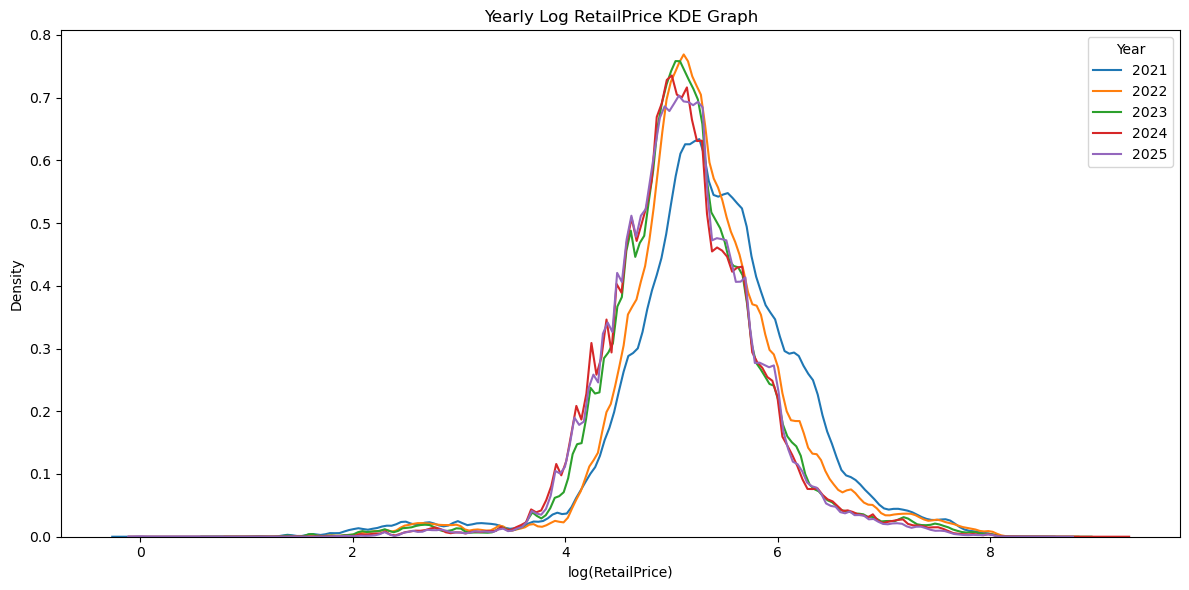

In [197]:
plt.figure(figsize=(12, 6))

# 년도별 반복
for year, group in df1.groupby('year'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    sns.kdeplot(log_prices, label=year, bw_adjust=0.7)


plt.xlabel('log(RetailPrice)')
plt.ylabel('Density')
plt.title('Yearly Log RetailPrice KDE Graph')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [122]:
int(np.exp(5.5))

244

#### 3.2 가격대별 히트맵 

In [126]:
df1 = df.copy()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_32980\2561297937.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('PriceBin')['RetailSales']


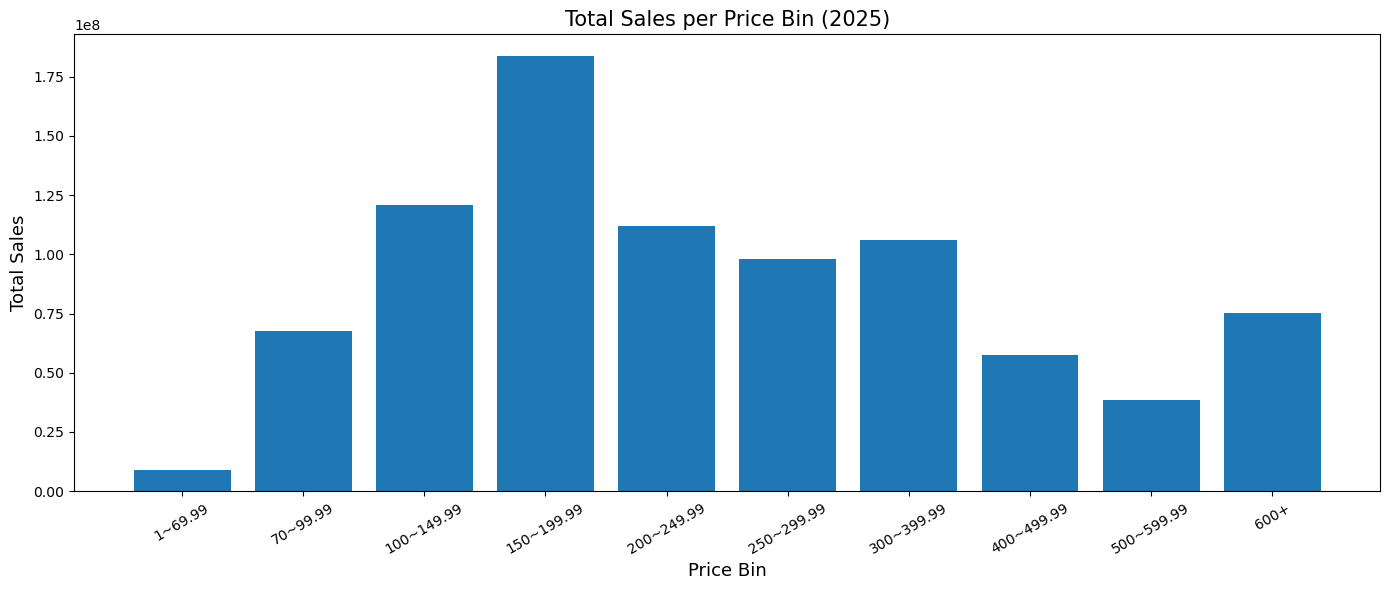

In [130]:
# 1. 2025년 + OTHERS 제외
df_filtered = df1[df['year'] == 2025].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,   # 왼쪽 포함, 오른쪽 미포함 (1~50은 1 <= x < 50)
    include_lowest=True
)

# 4. Price Bin별 매출 합계 집계
sales_by_bin = (
    df_filtered.groupby('PriceBin')['RetailSales']
    #df_filtered.groupby('PriceBin')['UnitsSold']
    .sum()
    .reindex(bin_labels)  # 빈 구간도 포함
)

# 5. 히스토그램(막대그래프) 시각화
plt.figure(figsize=(14,6))
plt.bar(sales_by_bin.index, sales_by_bin.values)
plt.xlabel("Price Bin", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)
plt.title("Total Sales per Price Bin (2025)", fontsize=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_32980\278389721.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby('PriceBin')['RetailSales']


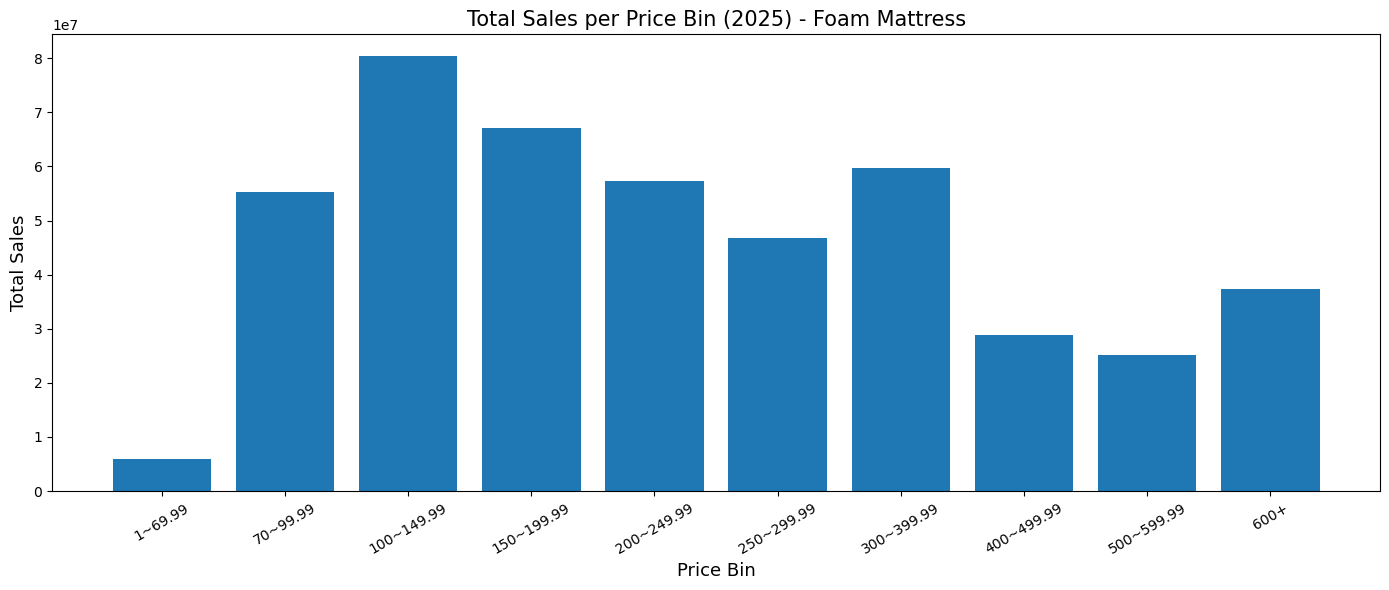

C:\Users\최태욱\AppData\Local\Temp\ipykernel_32980\278389721.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby('PriceBin')['RetailSales']


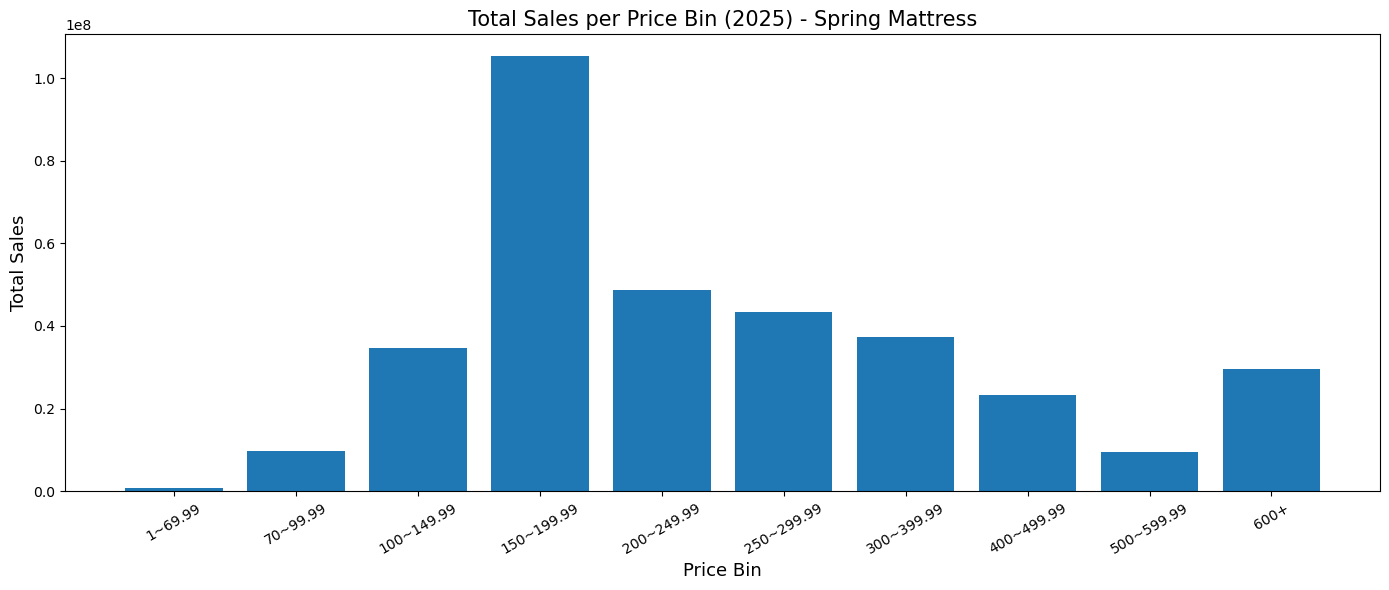

In [132]:
# 1. 2025년 데이터만 + OTHERS 제외
df_filtered = df1[(df1['year'] == 2025) & (df1['category'].isin(['Foam Mattress', 'Spring Mattress']))].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Foam/Spring 별로 반복
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_filtered[df_filtered['category'] == cat]
    sales_by_bin = (
        df_cat.groupby('PriceBin')['RetailSales']
        .sum()
        .reindex(bin_labels)  # 빈 구간도 포함
    )

    plt.figure(figsize=(14,6))
    plt.bar(sales_by_bin.index, sales_by_bin.values)
    plt.xlabel("Price Bin", fontsize=13)
    plt.ylabel("Total Sales", fontsize=13)
    plt.title(f"Total Sales per Price Bin (2025) - {cat}", fontsize=15)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\271820143.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']


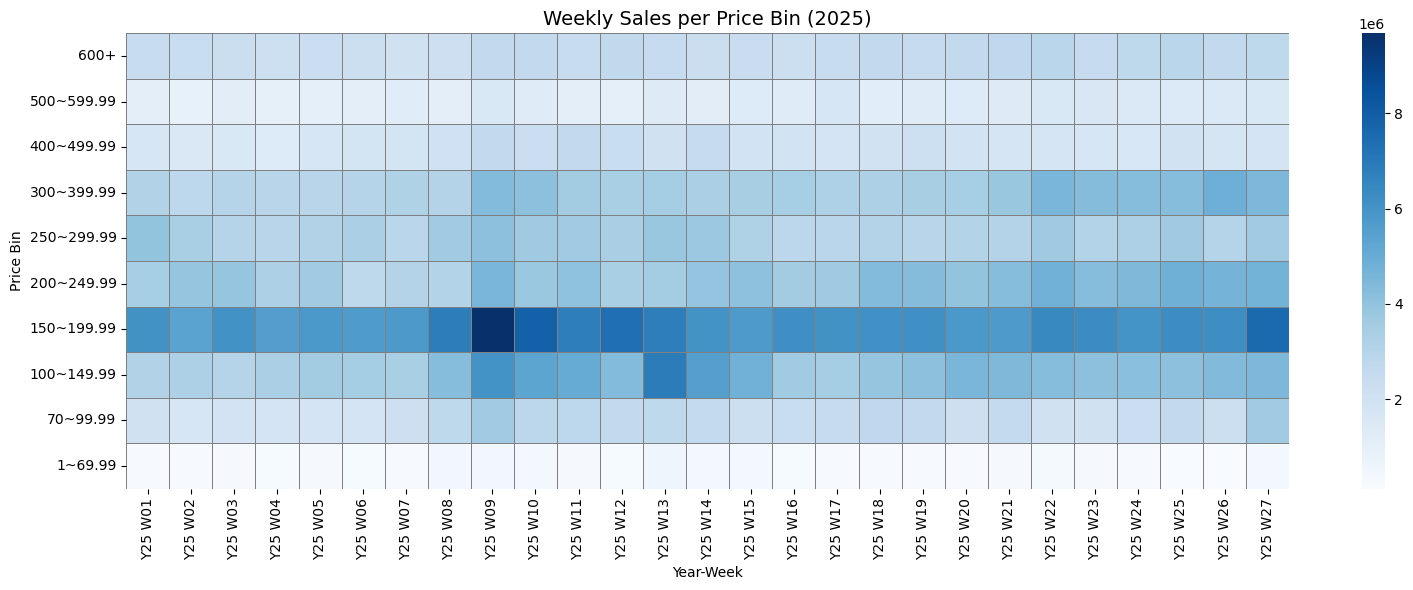

In [194]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Y축(Price Bin), X축(yr_week) 별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']
    .sum()
    .unstack(fill_value=0)
    .reindex(index=bin_labels[::-1])  # Y축 구간 순서 고정
)

# 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bin (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bin")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


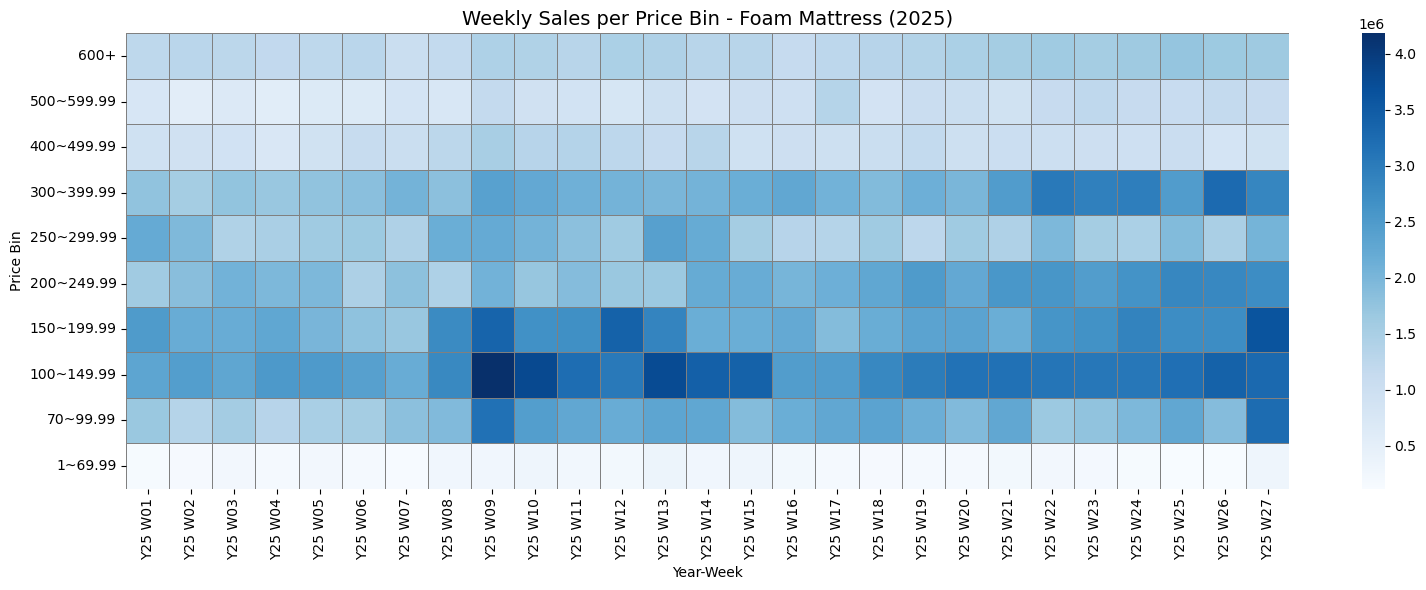

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


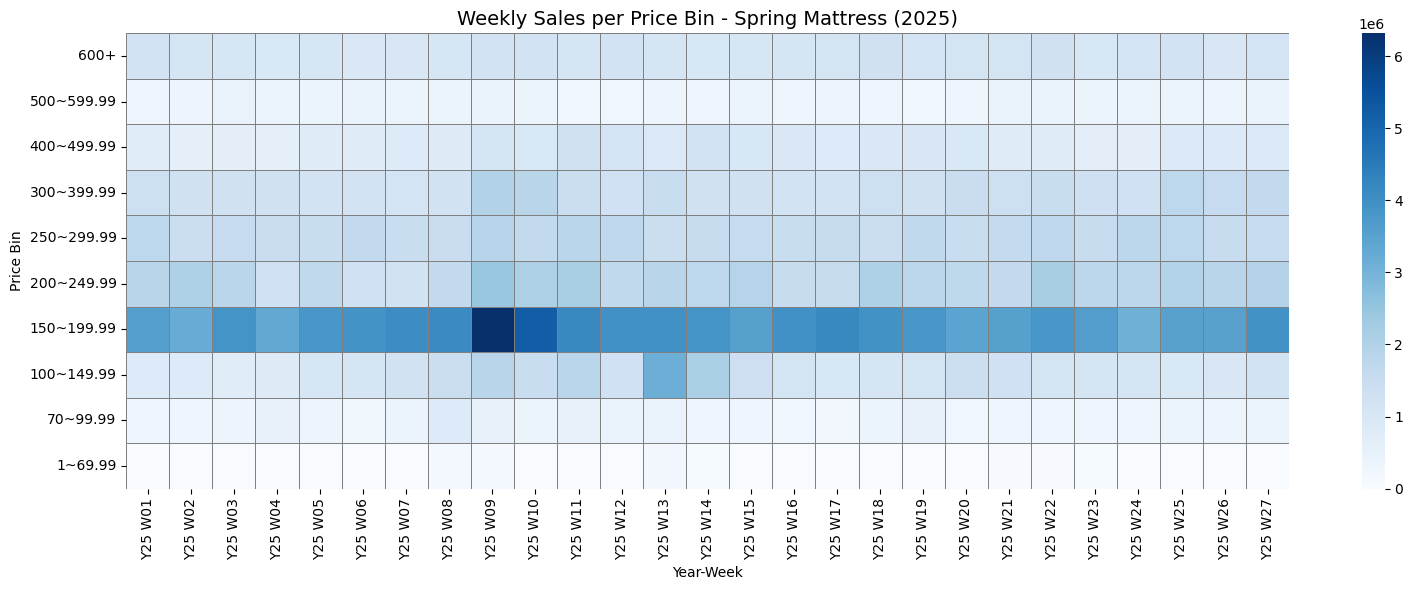

In [206]:
# Price Bin 설정
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

def draw_heatmap(df, category_name):
    df_cat = df[
        (df['category'] == category_name) & (df['year'] == 2025)
    ].copy()
    if len(df_cat) == 0:
        print(f"No data for {category_name}")
        return
    df_cat['PriceBin'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bin_labels,
        right=False,
        include_lowest=True
    )
    all_weeks = sorted(df_cat['yr_week'].unique())
    heatmap_data = (
        df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
        .reindex(index=bin_labels[::-1], columns=all_weeks, fill_value=0)
    )
    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bin - {category_name} (2025)", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bin")
    plt.tight_layout()
    plt.show()

# Foam Mattress
draw_heatmap(df, 'Foam Mattress')

# Spring Mattress
draw_heatmap(df, 'Spring Mattress')

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2227028325.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']


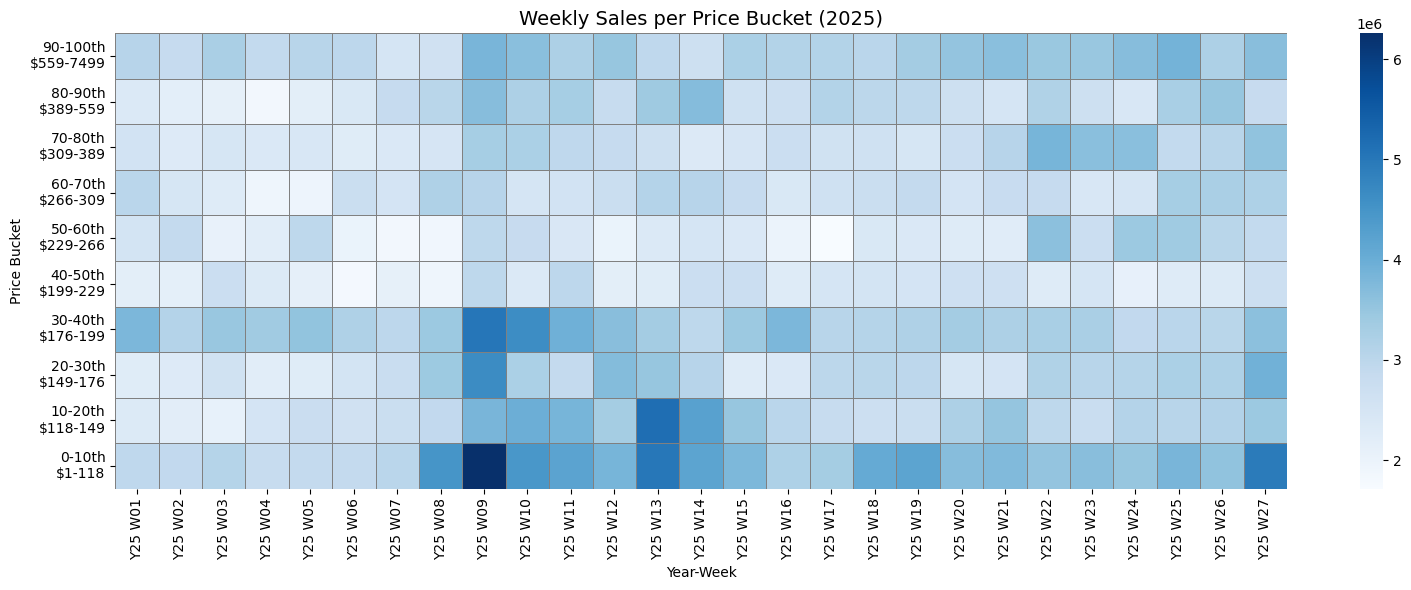

In [180]:

# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025) #&
    #(df['Brand_raw'] == 'ZINUS')
].copy()

# 2. 가격 퍼센타일 구간 계산 (2025년 전체 기준)
price_base = df_filtered['RetailPrice'].dropna()
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)

bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 3. 가격 버킷 할당
df_filtered['PriceBucket'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

# ✅ Y축 가격대 내림차순 정렬
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels[::-1],
    ordered=True
)

# ✅ 4. 가격대 × 주차별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']
               .sum()
               .unstack(fill_value=0)
)

# ✅ 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bucket (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bucket")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\3585644296.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']


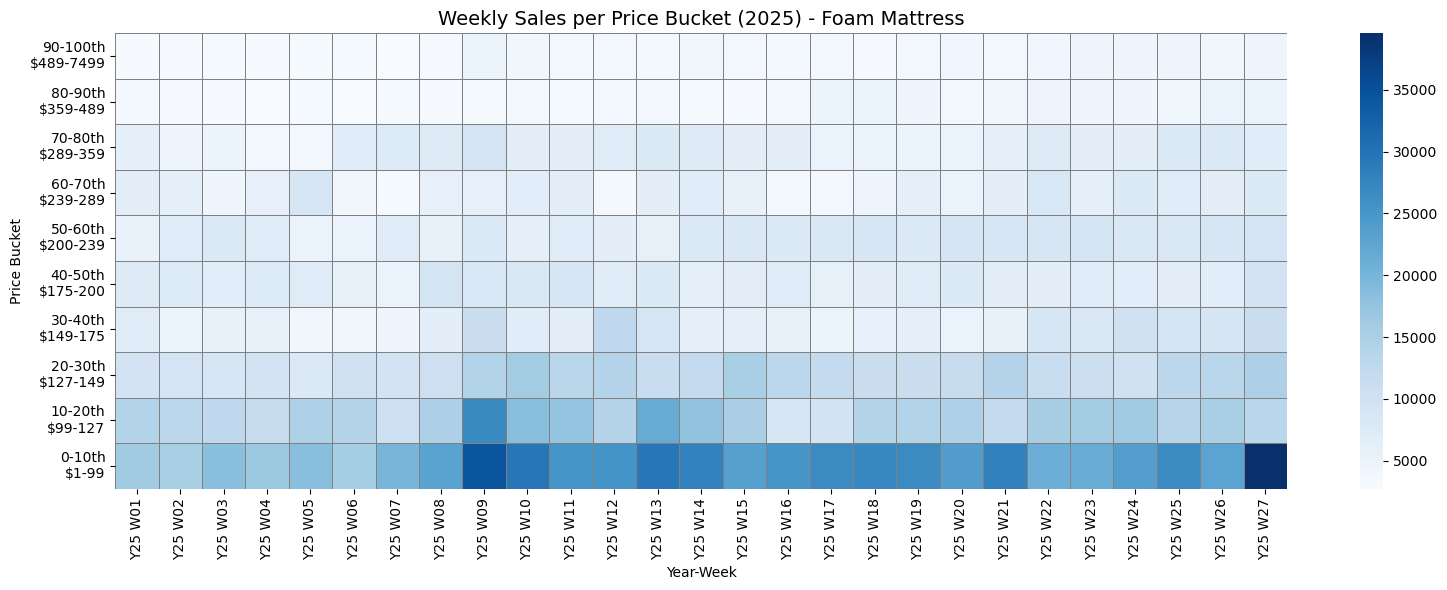

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\3585644296.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']


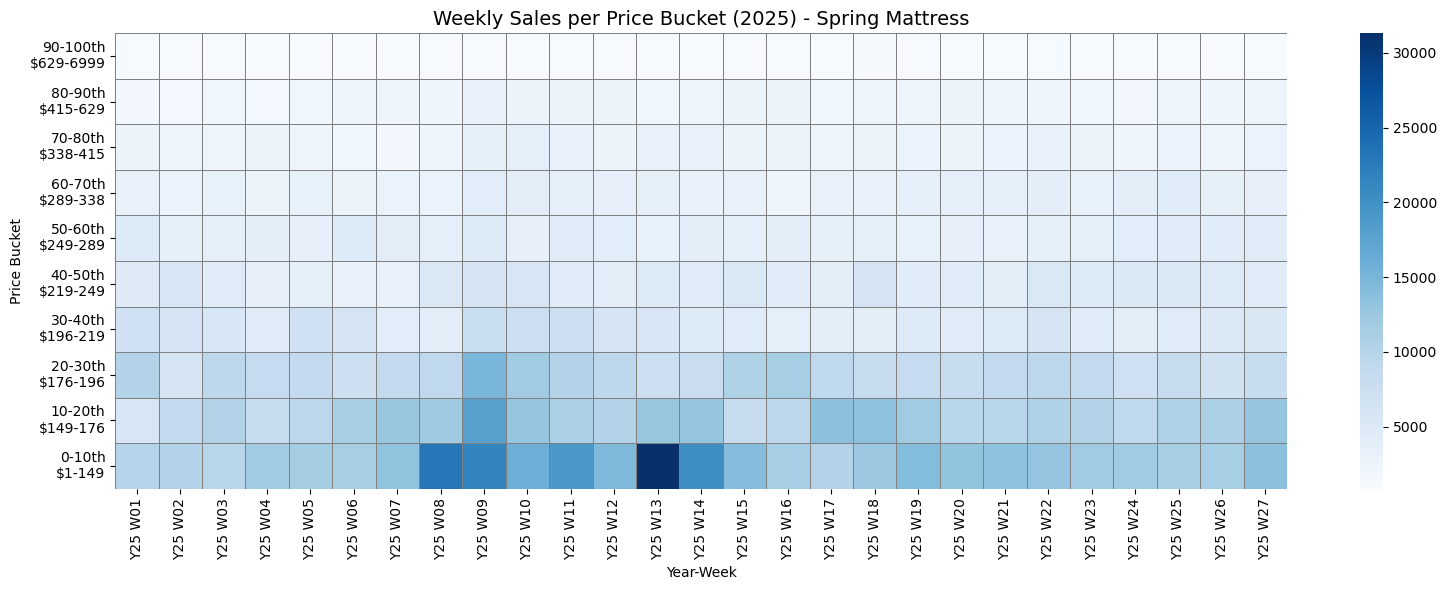

In [41]:

# 전처리: OTHERS 제외, 2025년만
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

category_list = ['Foam Mattress', 'Spring Mattress']

for cat in category_list:
    df_cat = df_filtered[df_filtered['category'] == cat].copy()
    # 가격 퍼센타일 구간 (해당 카테고리에서만)
    price_base = df_cat['RetailPrice'].dropna()
    if len(price_base) < 2:
        print(f"{cat} 데이터가 충분하지 않습니다.")
        continue

    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(price_base, q=percentiles)
    # 동일 가격 구간이 있으면 에러 발생 → 중복 제거
    price_bins = np.unique(price_bins)
    # 라벨 재생성 (bin 길이에 맞게)
    bucket_labels = [
        f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 가격 버킷 할당
    df_cat['PriceBucket'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )
    df_cat['PriceBucket'] = pd.Categorical(
        df_cat['PriceBucket'],
        categories=bucket_labels[::-1],
        ordered=True
    )

    # 히트맵용 데이터
    heatmap_data = (
        #df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']
        df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']
              .sum()
              .unstack(fill_value=0)
    )

    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bucket (2025) - {cat}", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bucket")
    plt.tight_layout()
    plt.show()

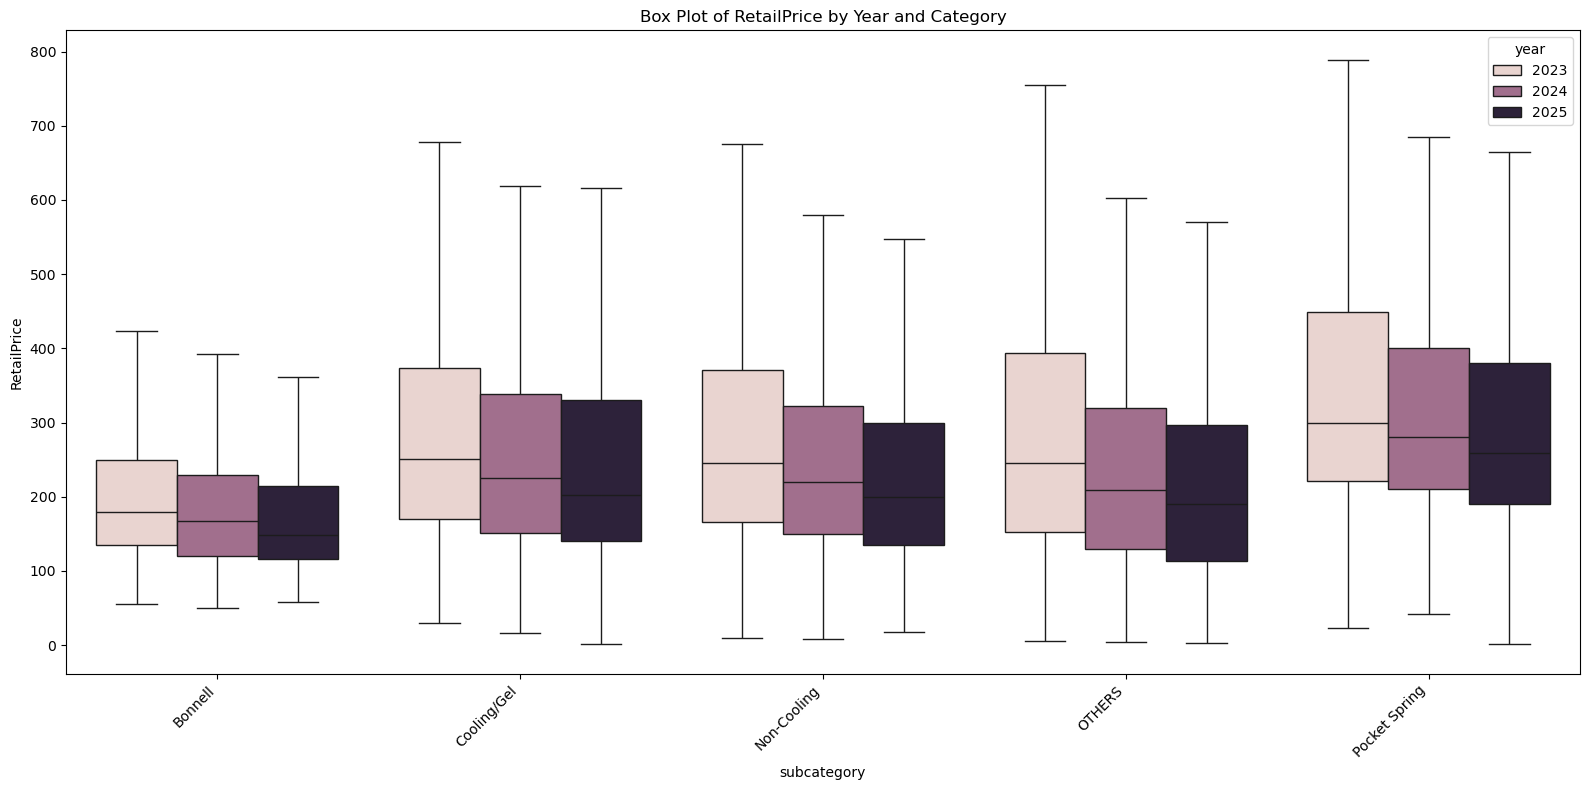

In [102]:

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df[df['RetailPrice'] > 0],  # 0 이하 제외 (로그변환 등에도 안전)
    x='subcategory',
    y='RetailPrice',
    hue='year',        # 분기로 색 구분
    showfliers=False         # 이상치 점 표시 안함 (원하면 True로)
)

plt.xticks(rotation=45, ha='right')
plt.title('Box Plot of RetailPrice by Year and Category')
plt.ylabel('RetailPrice')
plt.tight_layout()
plt.legend(title='year')
plt.show()

### 4. Market Share 분석

In [135]:
df1 = df.copy()

In [137]:
# 1. 2025년 데이터 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# 2. Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 3. CSV로 저장
brand_sales_2025.to_csv('brand_sales_2025_sorted.csv', index=False)

# (선택) 상위 5개 출력
print(brand_sales_2025.head())

    Brand_raw   RetailSales
610     ZINUS  1.401663e+08
386   NOVILLA  6.276125e+07
168       FDW  3.963378e+07
352     MLILY  3.545190e+07
375    NECTAR  3.312092e+07


In [166]:
print(brand_sales_2025['Brand_raw'].nunique())

619


In [141]:
# 1. 2025년 + Foam/Spring만 필터링
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df1[(df1['year'] == 2025) & (df1['category'].isin(target_cats))].copy()

# 2. category, Brand_raw별 매출 합계 집계
brand_sales_by_cat = (
    df_2025.groupby(['category', 'Brand_raw'])['RetailSales']
           .sum()
           .reset_index()
)

# 3. category별 Top 10 브랜드 출력
topn = 10
for category, group in brand_sales_by_cat.groupby('category'):
    top_brands = group.sort_values(by='RetailSales', ascending=False).head(topn)
    print(f"\n[Category: {category}] Top {topn} Brands by RetailSales")
    print(top_brands[['Brand_raw', 'RetailSales']])


[Category: Foam Mattress] Top 10 Brands by RetailSales
               Brand_raw   RetailSales
297                ZINUS  1.143750e+08
192              NOVILLA  4.922243e+07
84                   FDW  3.957806e+07
172                MLILY  3.400318e+07
184               NECTAR  2.413848e+07
96                GAESTE  1.878955e+07
73               EGOHOME  1.292322e+07
50              COOL GEL  1.213054e+07
20   BEST PRICE MATTRESS  1.065620e+07
70               DYONERY  1.015861e+07

[Category: Spring Mattress] Top 10 Brands by RetailSales
                      Brand_raw  RetailSales
567                       ZINUS  25788347.47
321                    BEDSTORY  12725569.86
374                FP FLEXPEDIC  12281239.32
466                     NOVILLA  11658139.23
450                     MOLBIUS  11592986.92
551                   VESGANTTI  10312017.88
337                     COOLVIE  10161218.32
510  SIGNATURE DESIGN BY ASHLEY  10108251.09
408                     KOANTTI   7939715.86
462    

   yr_month  ZINUS_MarketShare(%)
0     23-01             21.630911
1     23-02             19.223365
2     23-03             21.851210
3     23-04             21.663981
4     23-05             17.962815
5     23-06             16.717315
6     23-07             19.217889
7     23-08             15.678568
8     23-09             14.528470
9     23-10             12.593751
10    23-11             12.986644
11    23-12             19.707853
12    24-01             16.110558
13    24-02             13.016853
14    24-03             15.205036
15    24-04             16.335339
16    24-05             14.540987
17    24-06             15.337745
18    24-07             14.346452
19    24-08             14.508770
20    24-09             16.601391
21    24-10             11.666375
22    24-11             12.799560
23    24-12             11.704315
24    25-01             14.275058
25    25-02             15.178152
26    25-03             16.301423
27    25-04             16.667450
28    25-05   

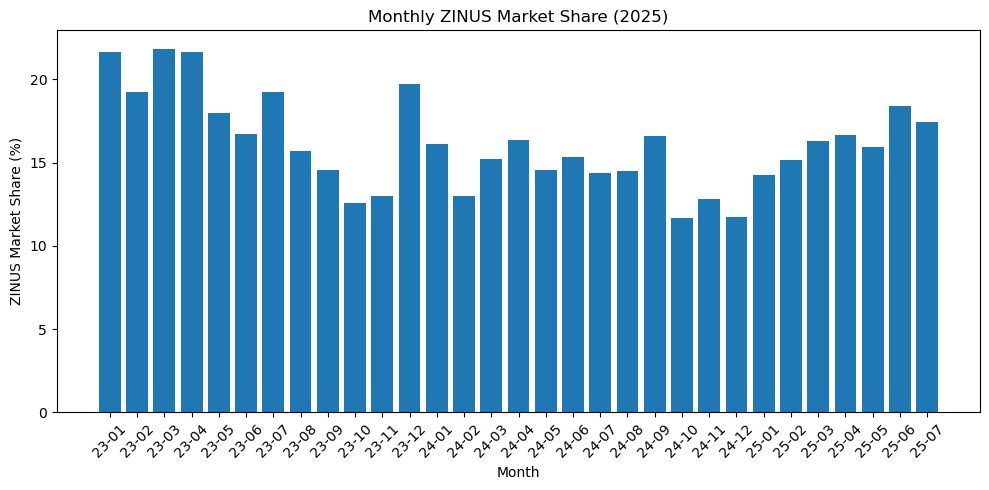

In [174]:
# 1. 2025년 데이터 필터링
#df_2025 = df1[df1['year'] == 2025].copy()

# 2. 월별 전체 매출 집계
monthly_total_sales = (
    df1.groupby('yr_month')['RetailSales']
           .sum()
           .reset_index()
           .rename(columns={'RetailSales': 'TotalSales'})
)

# 3. 월별 ZINUS 매출 집계
monthly_zinus_sales = (
    df1[df1['Brand_raw'].str.upper() == 'ZINUS']
    .groupby('yr_month')['RetailSales']
    .sum()
    .reset_index()
    .rename(columns={'RetailSales': 'ZinusSales'})
)

# 4. 월별 MarketShare(%) 계산
monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

# 5. 결과 출력
print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

plt.figure(figsize=(10, 5))
plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
plt.xlabel('Month')
plt.ylabel('ZINUS Market Share (%)')
plt.title('Monthly ZINUS Market Share (2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


[Category: Foam Mattress]
   yr_month  ZINUS_MarketShare(%)
0     23-01             28.628112
1     23-02             24.429491
2     23-03             28.568155
3     23-04             29.006693
4     23-05             23.316958
5     23-06             21.830175
6     23-07             25.616652
7     23-08             22.191880
8     23-09             19.807475
9     23-10             17.742008
10    23-11             19.048443
11    23-12             29.181941
12    24-01             24.537245
13    24-02             20.329131
14    24-03             24.725006
15    24-04             25.570044
16    24-05             22.434140
17    24-06             25.081021
18    24-07             20.894985
19    24-08             23.932235
20    24-09             29.306924
21    24-10             19.112802
22    24-11             19.906940
23    24-12             17.494542
24    25-01             21.928375
25    25-02             23.787957
26    25-03             26.633516
27    25-04          

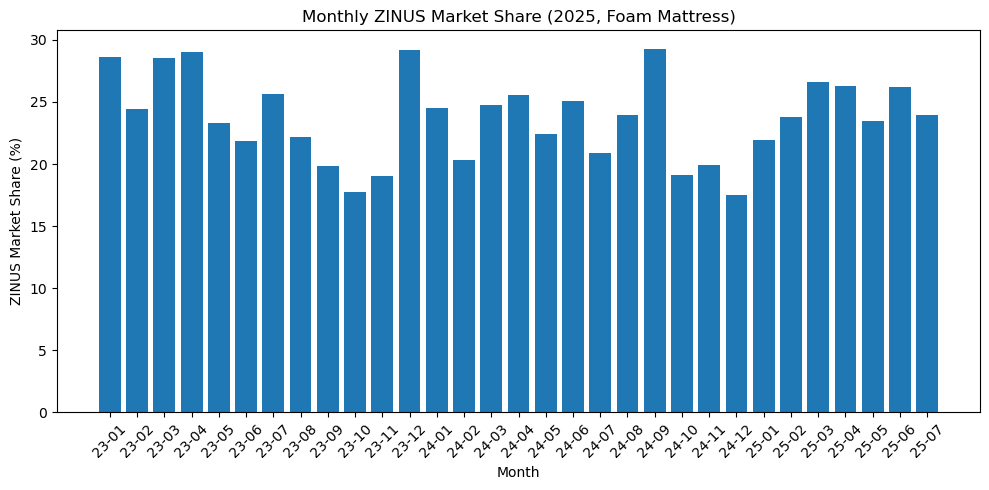


[Category: Spring Mattress]
   yr_month  ZINUS_MarketShare(%)
0     23-01             11.268434
1     23-02             12.879992
2     23-03             13.410256
3     23-04             11.429523
4     23-05             11.296230
5     23-06             10.354024
6     23-07             10.622993
7     23-08              8.035823
8     23-09              9.253170
9     23-10              7.116290
10    23-11              6.051045
11    23-12              9.108785
12    24-01              7.538744
13    24-02              6.787448
14    24-03              6.261483
15    24-04              6.900212
16    24-05              6.952270
17    24-06              7.033318
18    24-07              9.412910
19    24-08              6.780195
20    24-09              6.036159
21    24-10              5.382894
22    24-11              6.230600
23    24-12              5.948663
24    25-01              7.517555
25    25-02              7.524375
26    25-03              6.489518
27    25-04        

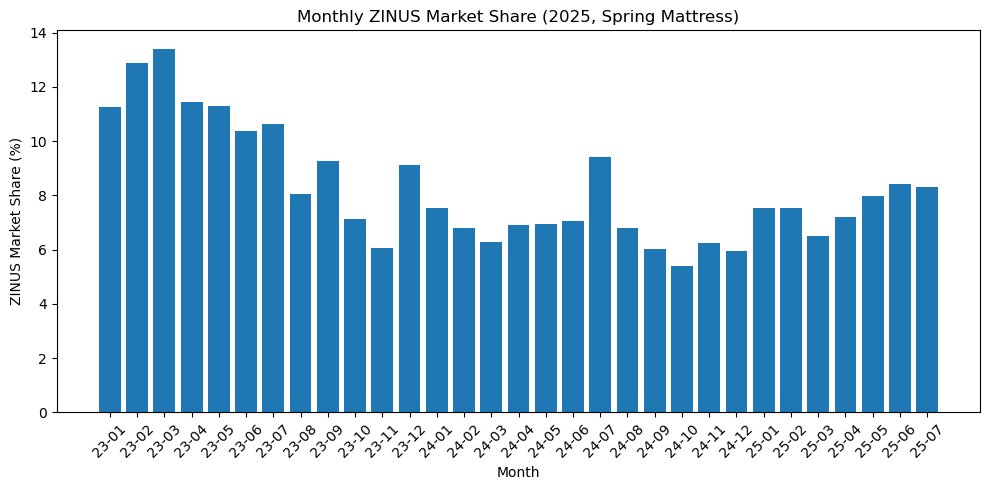

In [176]:
categories = ['Foam Mattress', 'Spring Mattress']

for cat in categories:
    # 1. 해당 카테고리만 필터링
    df_cat = df1[df1['category'] == cat].copy()
    
    # 2. 월별 전체 매출 집계
    monthly_total_sales = (
        df_cat.groupby('yr_month')['RetailSales']
              .sum()
              .reset_index()
              .rename(columns={'RetailSales': 'TotalSales'})
    )

    # 3. 월별 ZINUS 매출 집계
    monthly_zinus_sales = (
        df_cat[df_cat['Brand_raw'].str.upper() == 'ZINUS']
        .groupby('yr_month')['RetailSales']
        .sum()
        .reset_index()
        .rename(columns={'RetailSales': 'ZinusSales'})
    )

    # 4. 월별 MarketShare(%) 계산
    monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
    monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
    monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

    # 5. 결과 출력 (옵션)
    print(f"\n[Category: {cat}]")
    print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

    # 6. 막대그래프
    plt.figure(figsize=(10, 5))
    plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
    plt.xlabel('Month')
    plt.ylabel('ZINUS Market Share (%)')
    plt.title(f'Monthly ZINUS Market Share (2025, {cat})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

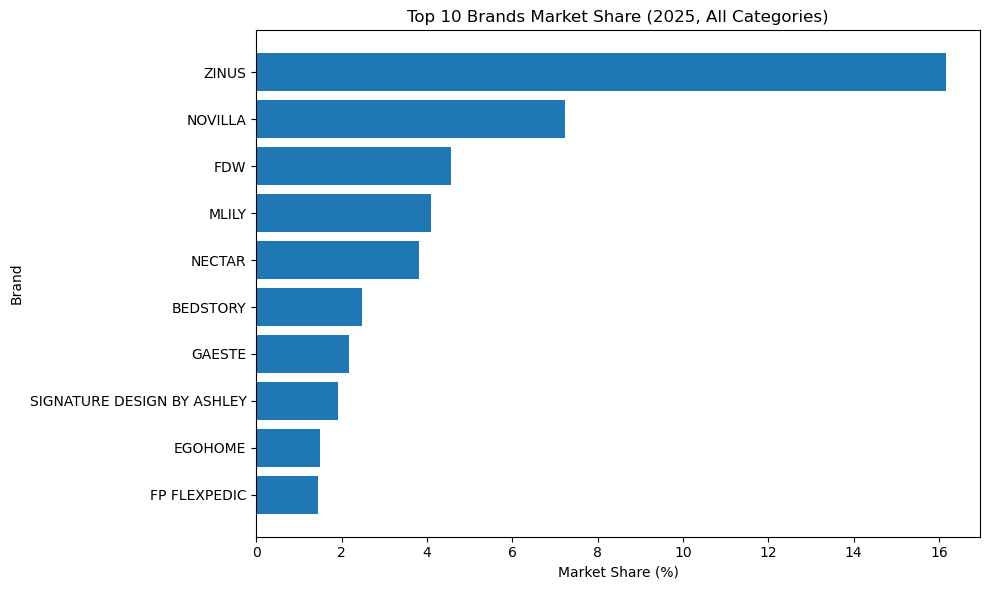

In [168]:
opn = 10

# 1. 2025년 전체 데이터만 사용 (category 구분 X)
df_2025_total = df1[df1['year'] == 2025]

# 2. 브랜드별 매출 집계
brand_sales_all = (
    df_2025_total.groupby('Brand_raw')['RetailSales']
                 .sum()
                 .reset_index()
                 .sort_values(by='RetailSales', ascending=False)
)

# 3. Top 10 브랜드 및 Others 계산
top_brands = brand_sales_all.head(topn).copy()
others_sales = brand_sales_all['RetailSales'][topn:].sum()

# 4. MarketShare 계산 (Top10 + Others 기준)
total_sales = top_brands['RetailSales'].sum() + others_sales
top_brands['MarketShare'] = top_brands['RetailSales'] / total_sales * 100

# 5. 그래프 (Top10만 표시)
plt.figure(figsize=(10, 6))
plt.barh(top_brands['Brand_raw'], top_brands['MarketShare'])
plt.xlabel('Market Share (%)')
plt.ylabel('Brand')
plt.title('Top 10 Brands Market Share (2025, All Categories)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

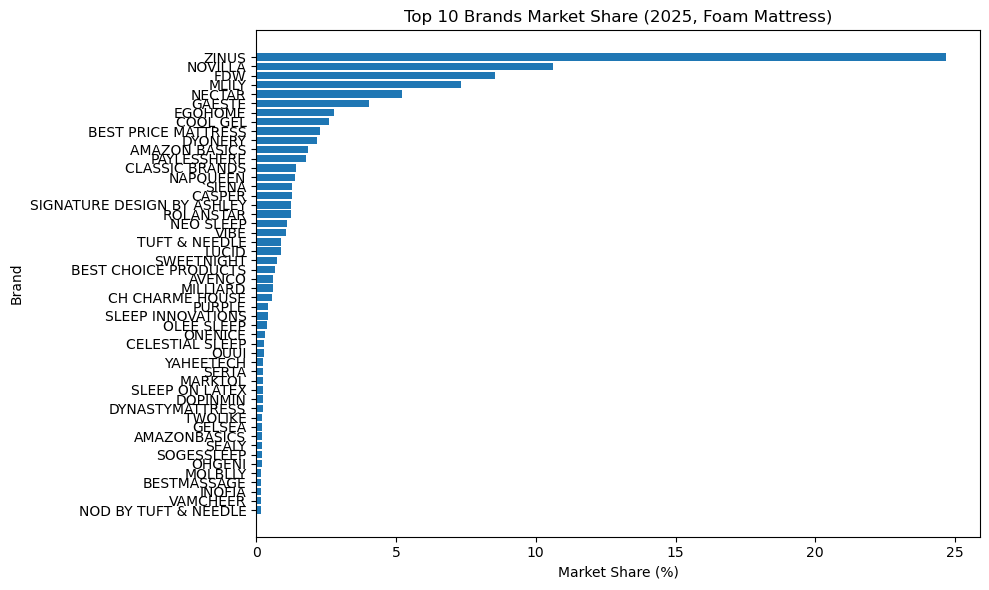

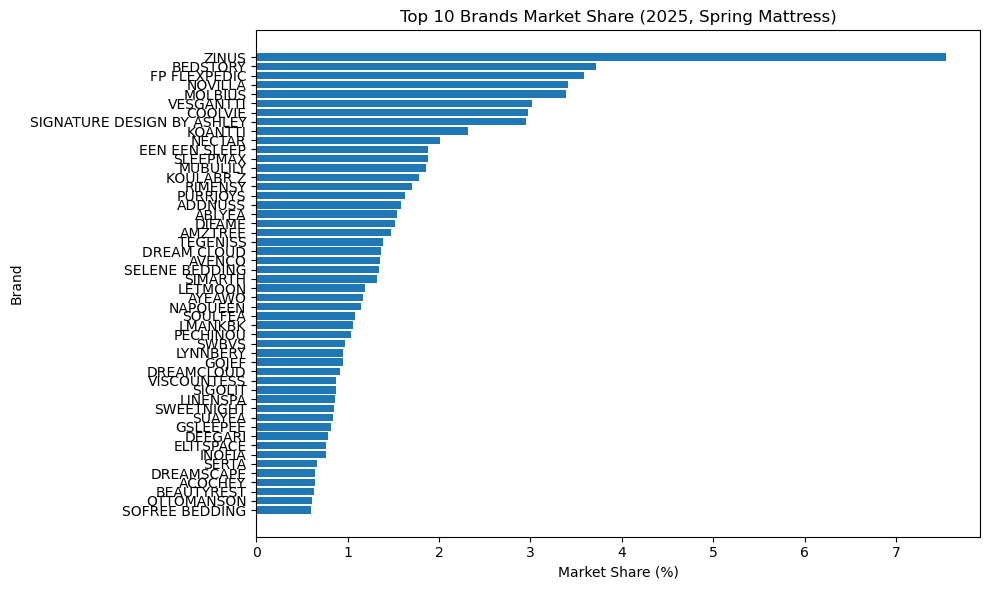

In [180]:
categories = ['Foam Mattress', 'Spring Mattress']
topn = 50

for cat in categories:
    df_2025_cat = df1[(df1['year'] == 2025) & (df1['category'] == cat)]
    
    # 전체 브랜드 매출 집계
    brand_sales_all = (
        df_2025_cat.groupby('Brand_raw')['RetailSales']
                   .sum()
                   .reset_index()
                   .sort_values(by='RetailSales', ascending=False)
    )
    
    # Top 10 추출 및 Others 계산
    top_brands = brand_sales_all.head(topn).copy()
    others_sales = brand_sales_all['RetailSales'][topn:].sum()
    
    # MarketShare 계산 (Top10 + Others 기준)
    total_sales = top_brands['RetailSales'].sum() + others_sales
    top_brands['MarketShare'] = top_brands['RetailSales'] / total_sales * 100
    
    # 그래프 (Top10만 표시)
    plt.figure(figsize=(10, 6))
    plt.barh(top_brands['Brand_raw'], top_brands['MarketShare'])
    plt.xlabel('Market Share (%)')
    plt.ylabel('Brand')
    plt.title(f'Top 10 Brands Market Share (2025, {cat})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

   yr_month  ZINUS_MarketShare(%)
0     23-01              9.447689
1     23-02              9.851803
2     23-03              9.348261
3     23-04             10.021913
4     23-05             10.159380
5     23-06              7.334778
6     23-07              7.393668
7     23-08              6.271916
8     23-09              6.256496
9     23-10              5.410728
10    23-11              4.626941
11    23-12              6.696563
12    24-01              5.776762
13    24-02              5.017301
14    24-03              4.896707
15    24-04              4.752167
16    24-05              4.997880
17    24-06              5.321370
18    24-07              6.943784
19    24-08              4.201077
20    24-09              3.416354
21    24-10              3.776430
22    24-11              4.152049
23    24-12              2.931926
24    25-01              3.218521
25    25-02              3.123281
26    25-03              2.972973
27    25-04              4.174873
28    25-05   

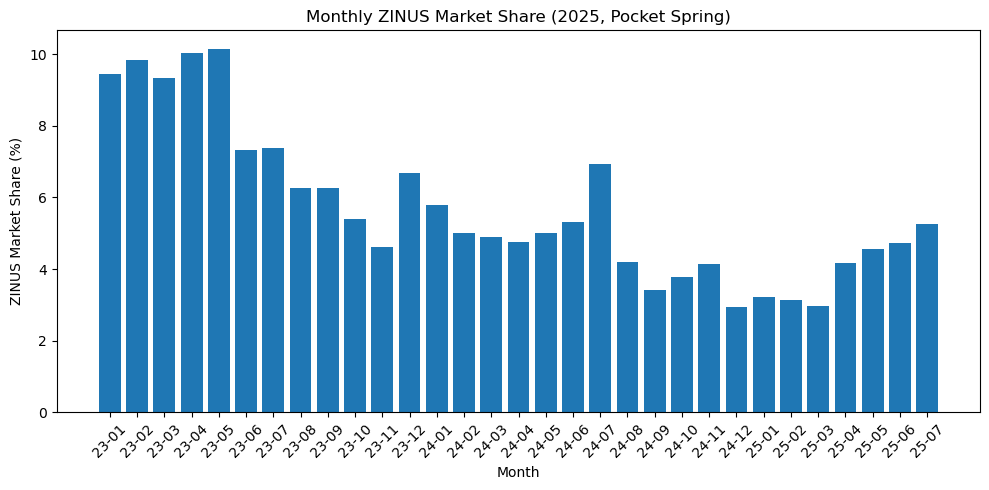

In [183]:

# 1. pocket spring만 필터링
df_pocket = df1[(df1['category'] == 'Spring Mattress') & (df1['subcategory'] == 'Pocket Spring')]

# 2. 월별 전체 매출 집계
monthly_total_sales = (
    df_pocket.groupby('yr_month')['RetailSales']
             .sum()
             .reset_index()
             .rename(columns={'RetailSales': 'TotalSales'})
)

# 3. 월별 ZINUS 매출 집계
monthly_zinus_sales = (
    df_pocket[df_pocket['Brand_raw'].str.upper() == 'ZINUS']
    .groupby('yr_month')['RetailSales']
    .sum()
    .reset_index()
    .rename(columns={'RetailSales': 'ZinusSales'})
)

# 4. 월별 MarketShare(%) 계산
monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

# 5. 결과 출력 (옵션)
print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

# 6. 막대그래프
plt.figure(figsize=(10, 5))
plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
plt.xlabel('Month')
plt.ylabel('ZINUS Market Share (%)')
plt.title('Monthly ZINUS Market Share (2025, Pocket Spring)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                      Brand_raw  RetailSales  MarketShare(%)
21                     BEDSTORY  12725569.86        4.017779
73                 FP FLEXPEDIC  12281239.32        3.877493
260                       ZINUS  12140687.16        3.833117
146                     MOLBIUS  11592986.92        3.660194
161                     NOVILLA  11091284.60        3.501795
244                   VESGANTTI  10312017.88        3.255761
36                      COOLVIE  10161218.32        3.208149
204  SIGNATURE DESIGN BY ASHLEY   9995142.88        3.155715
106                     KOANTTI   7939715.86        2.506766
157                      NECTAR   6872422.27        2.169795
58                EEN EEN SLEEP   6433890.91        2.031339
211                    SLEEPMAX   6427611.60        2.029357
150                    MUBULILY   6368115.20        2.010572
108                   KOULABR Z   6104652.07        1.927391
188                     RIMENSY   5842663.43        1.844674
184                    P

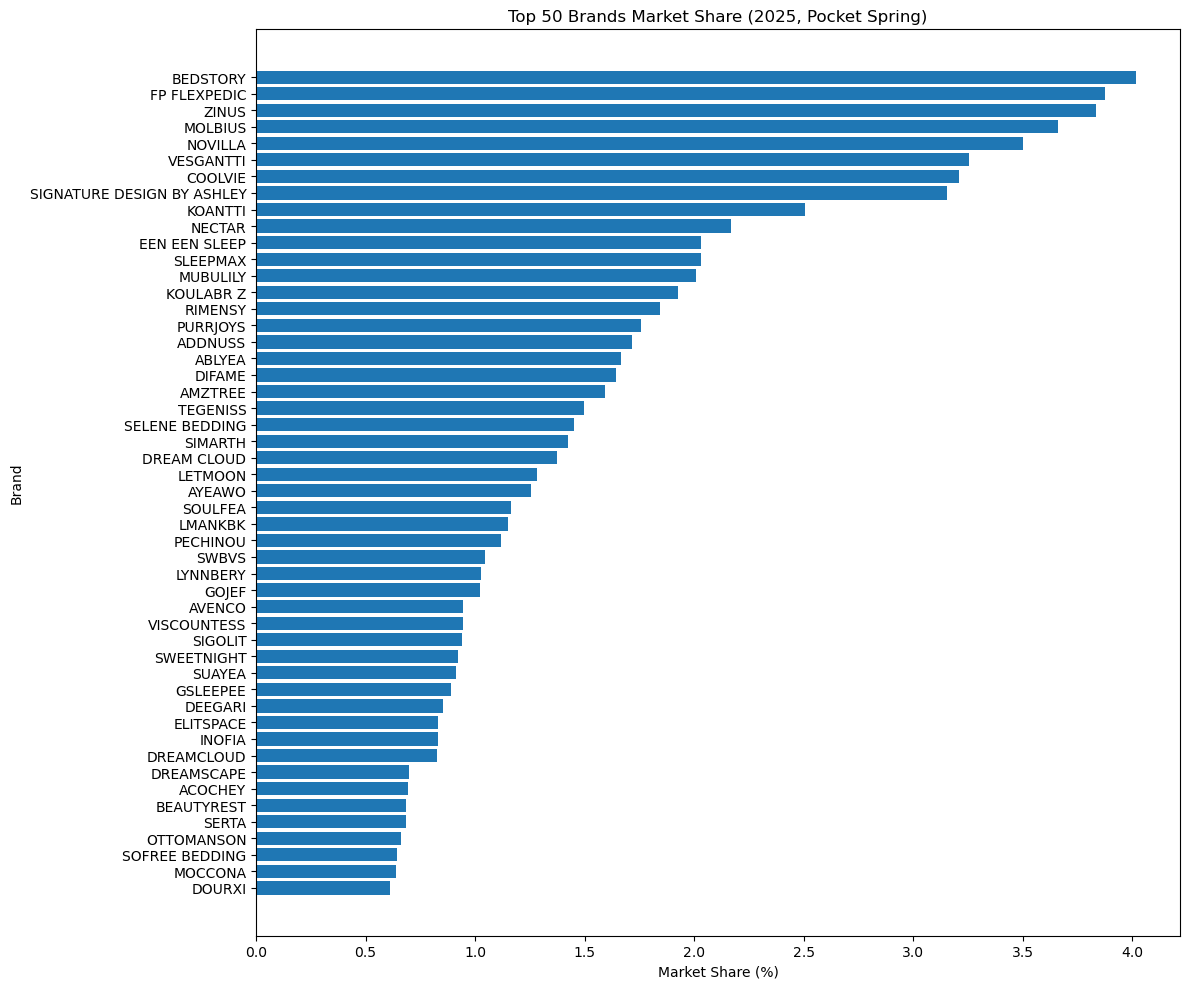

In [185]:
# 1. pocket spring 필터링 (2025년, Spring Mattress, pocket spring)
df_pocket = df1[
    (df1['year'] == 2025) &
    (df1['category'] == 'Spring Mattress') &
    (df1['subcategory'].str.lower() == 'pocket spring')
]

# 2. 브랜드별 매출 합계 집계 (내림차순 정렬)
brand_sales = (
    df_pocket.groupby('Brand_raw')['RetailSales']
             .sum()
             .reset_index()
             .sort_values(by='RetailSales', ascending=False)
)

# 3. Top 50 추출
topn = 50
top_brands = brand_sales.head(topn).copy()

# 4. 전체 매출 합계
total_sales = brand_sales['RetailSales'].sum()

# 5. 시장점유율(%) 계산
top_brands['MarketShare(%)'] = top_brands['RetailSales'] / total_sales * 100

# 6. 결과 확인
print(top_brands[['Brand_raw', 'RetailSales', 'MarketShare(%)']])

# (선택) 그래프
plt.figure(figsize=(12, 10))
plt.barh(top_brands['Brand_raw'], top_brands['MarketShare(%)'])
plt.xlabel('Market Share (%)')
plt.ylabel('Brand')
plt.title('Top 50 Brands Market Share (2025, Pocket Spring)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
topn = 10

for category, group in brand_sales_by_cat.groupby('category'):
    # 1. 매출 기준 정렬
    group_sorted = group.sort_values(by='RetailSales', ascending=False).reset_index(drop=True)
    # 2. Top N 브랜드
    top_brands = group_sorted.head(topn)
    # 3. Others 계산
    others = group_sorted.iloc[topn:]
    others_sales = others['RetailSales'].sum()
    # 4. Top N + Others 데이터프레임 생성
    result = top_brands[['Brand_raw', 'RetailSales']].copy()
    if others_sales > 0:
        others_row = pd.DataFrame({
            'Brand_raw': ['Others'],
            'RetailSales': [others_sales]
        })
        result = pd.concat([result, others_row], ignore_index=True)
    # 5. 비율 컬럼 추가
    total_sales = result['RetailSales'].sum()
    result['SalesRatio'] = (result['RetailSales'] / total_sales * 100).round(2)
    # 6. 출력
    print(f"\n[Category: {category}] Top {topn} Brands (+Others) by RetailSales")
    print(result)

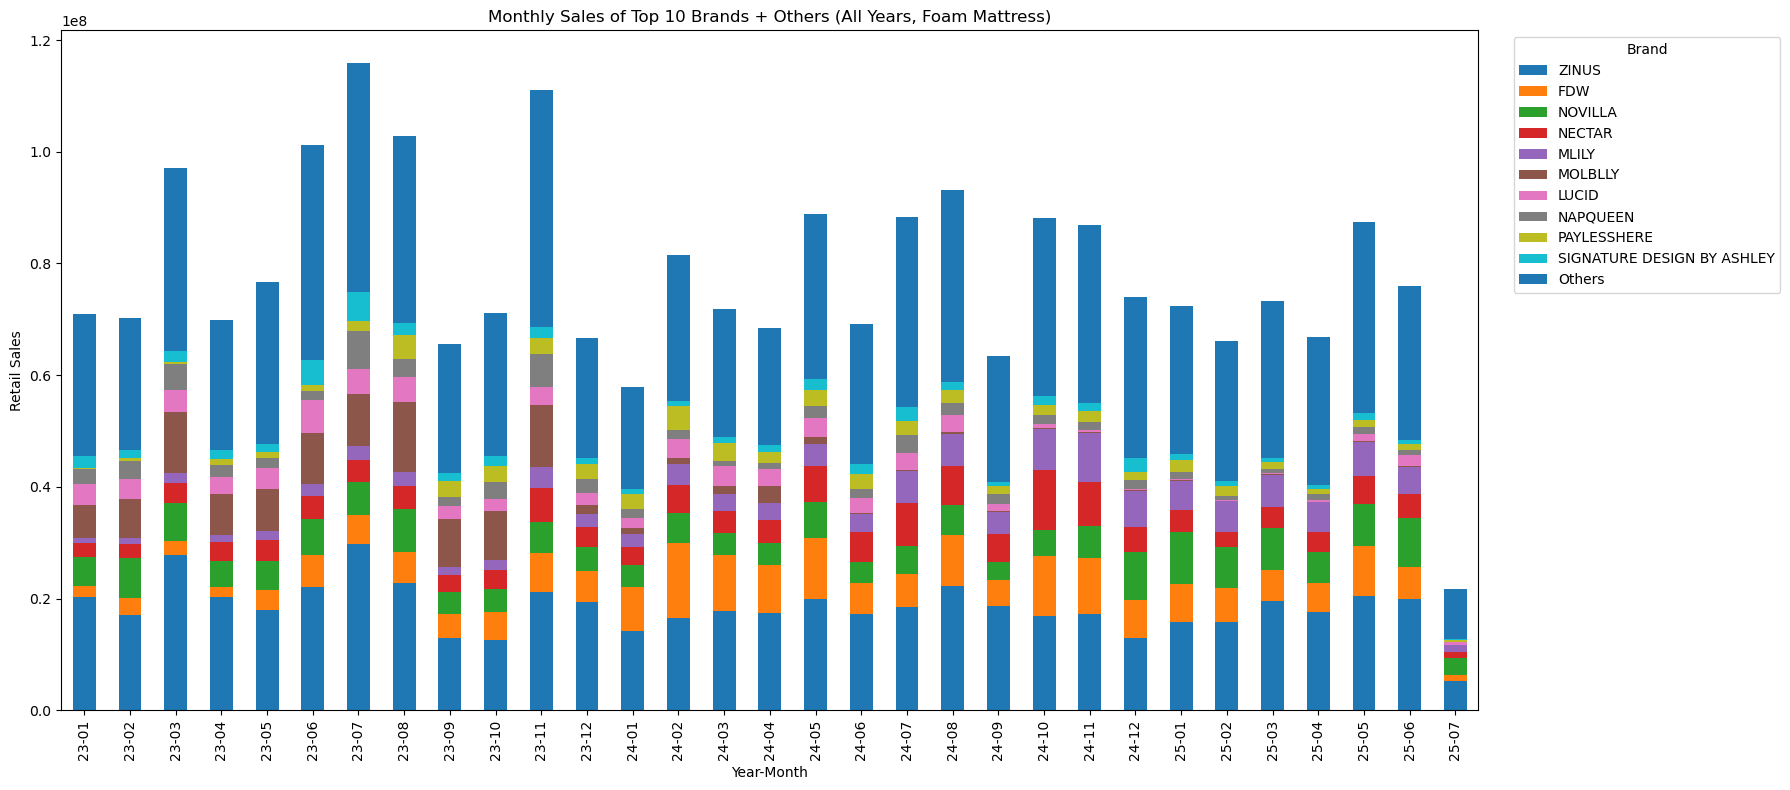

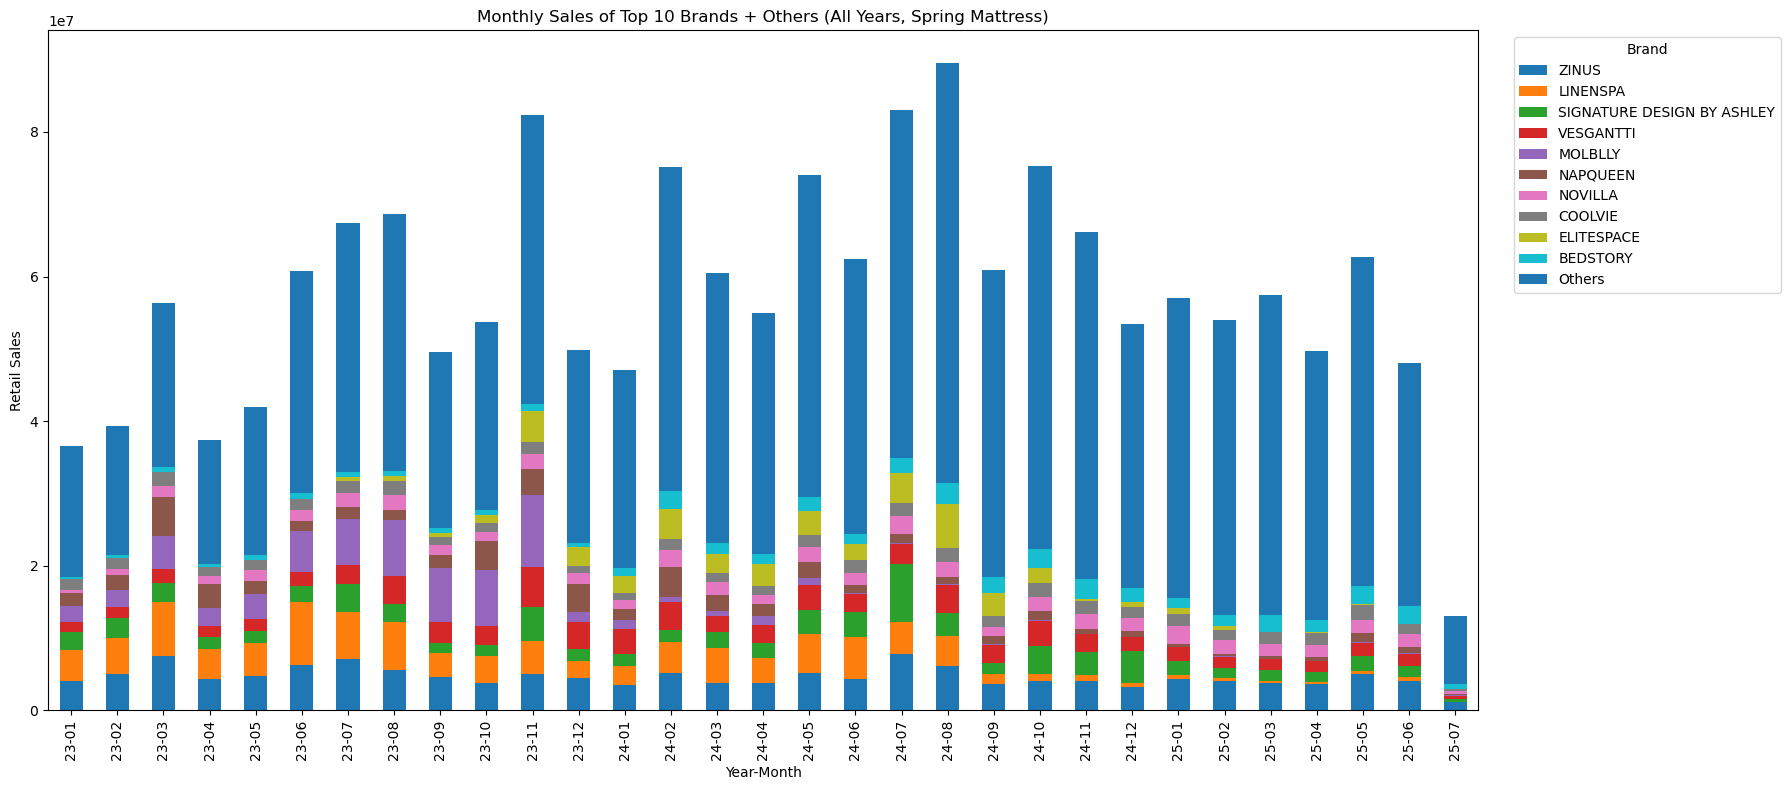

In [157]:
target_cats = ['Foam Mattress', 'Spring Mattress']

for cat in target_cats:
    # 1. 카테고리별 전체 데이터 추출
    df_cat = df1[df1['category'] == cat].copy()
    if df_cat.empty:
        continue

    # 2. 연/월, 브랜드별 매출 집계 (yr_month 사용)
    monthly_brand_sales = (
        df_cat.groupby(['yr_month', 'Brand_raw'])['RetailSales']
              .sum()
              .reset_index()
    )

    # 3. 전체 기간 Top 10 브랜드 선정
    top_brands = (
        monthly_brand_sales.groupby('Brand_raw')['RetailSales']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    # 4. Others 처리
    monthly_brand_sales['Brand_Plot'] = monthly_brand_sales['Brand_raw'].where(
        monthly_brand_sales['Brand_raw'].isin(top_brands), 'Others'
    )

    # 5. Others 포함 월별 합계 재집계
    monthly_plot = (
        monthly_brand_sales.groupby(['yr_month', 'Brand_Plot'])['RetailSales']
        .sum()
        .reset_index()
    )

    # 6. Pivot (Top 10 + Others)
    plot_brands = list(top_brands) + ['Others']
    pivot = monthly_plot.pivot(index='yr_month', columns='Brand_Plot', values='RetailSales').fillna(0)
    pivot = pivot[[b for b in plot_brands if b in pivot.columns]]

    # 7. 누적 막대그래프 그리기
    plt.figure(figsize=(18, 8))
    pivot.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title(f'Monthly Sales of Top 10 Brands + Others (All Years, {cat})')
    plt.xlabel('Year-Month')
    plt.ylabel('Retail Sales')
    plt.legend(title='Brand', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

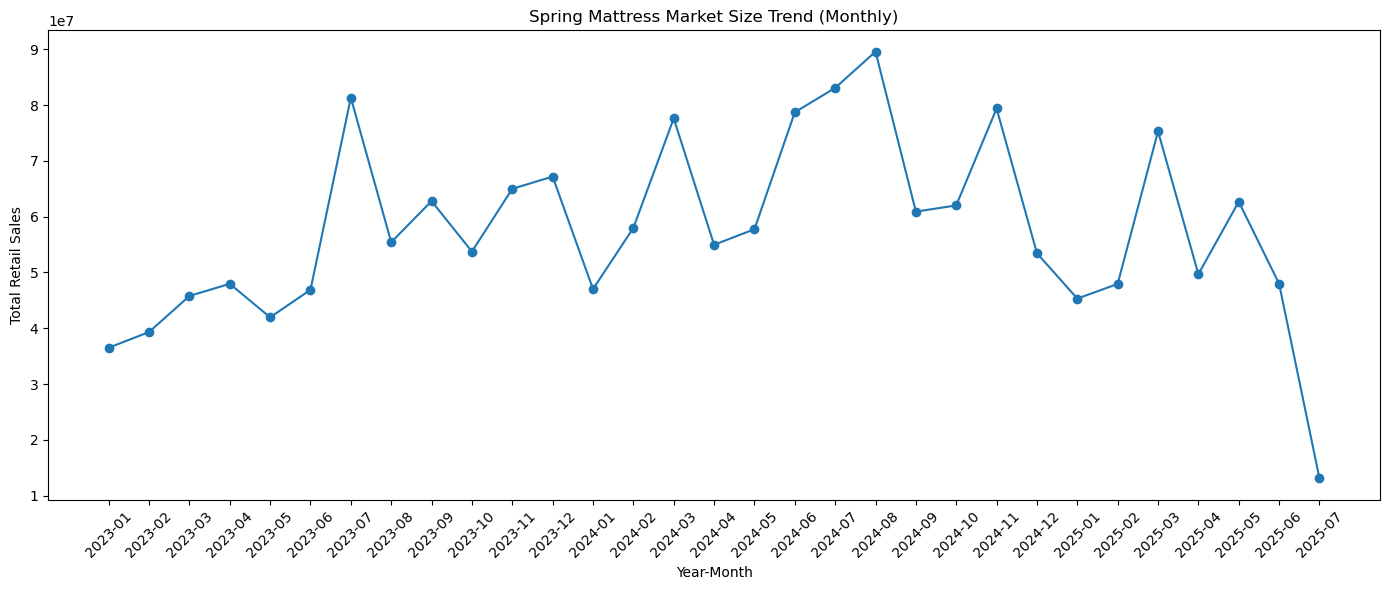

In [153]:

# 1. Spring Mattress 데이터만 추출
df_spring = df1[df1['category'] == 'Spring Mattress'].copy()

# 2. 연/월 추출 (WeekEnding 기준)
df_spring['YearMonth'] = pd.to_datetime(df_spring['WeekEnding']).dt.to_period('M')

# 3. 연/월별 매출 합계 집계
monthly_market = (
    df_spring.groupby('YearMonth')['RetailSales']
    .sum()
    .reset_index()
)

# 4. 라인그래프로 시장 크기 추이 시각화
plt.figure(figsize=(14, 6))
plt.plot(monthly_market['YearMonth'].astype(str), monthly_market['RetailSales'], marker='o')
plt.title('Spring Mattress Market Size Trend (Monthly)')
plt.xlabel('Year-Month')
plt.ylabel('Total Retail Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()